In [55]:
%pip install pandas numpy matplotlib seaborn geopandas shapely statsmodels scikit-learn

import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely import wkt
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
from sklearn.tree import plot_tree
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import statsmodels.api as sm


[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [56]:
ridership = pd.read_csv("resources/ridership_by_station.csv", dtype={'station_id': str})
ridership.head()

,station_id,stationname,date,daytype,rides
0,41280,Jefferson Park,12/22/2017,W,6104
1,41000,Cermak-Chinatown,12/18/2017,W,3636
2,40280,Central-Lake,12/02/2017,A,1270
3,40140,Dempster-Skokie,12/19/2017,W,1759
4,40690,Dempster,12/03/2017,U,499


In [57]:
ridership['date'] = pd.to_datetime(ridership['date'])
ridership['daytype'] = ridership['daytype'].astype('category')
ridership['rides'] = pd.to_numeric(ridership['rides'], errors='coerce')
ridership['station_id'] = pd.to_numeric(ridership['station_id'], errors='coerce')
ridership.info()

<class 'pandas.DataFrame'>
RangeIndex: 1298399 entries, 0 to 1298398
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   station_id   1298399 non-null  int64         
 1   stationname  1298399 non-null  str           
 2   date         1298399 non-null  datetime64[us]
 3   daytype      1298399 non-null  category      
 4   rides        1298399 non-null  int64         
dtypes: category(1), datetime64[us](1), int64(2), str(1)
memory usage: 40.9 MB


In [58]:
ridership.head()

,station_id,stationname,date,daytype,rides
0,41280,Jefferson Park,2017-12-22,W,6104
1,41000,Cermak-Chinatown,2017-12-18,W,3636
2,40280,Central-Lake,2017-12-02,A,1270
3,40140,Dempster-Skokie,2017-12-19,W,1759
4,40690,Dempster,2017-12-03,U,499


In [59]:
#Import weather data
with open('weather_data.pkl', 'rb') as f:
    weather = pickle.load(f)
weather.head()

,STATION,NAME,DATE,AWND,PRCP,SNOW,SNWD,TAVG,Fog_Ice_Fog,Heavy_Fog,Thunder,Ice_Pellets_Sleet,Hail,Glaze_Rime,Dust_Ash_Sand,Smoke_Haze,Blowing_Snow,Tornado_Funnel_Cloud,High_Winds
0,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-01,7.38,0.00,0.0,0.0,42.0,0,0,0,0,0,0,0,0,0,0,0
1,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-02,13.87,0.01,0.0,0.0,48.0,1,0,0,0,0,0,0,0,0,0,0
2,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-03,12.75,0.25,0.4,0.0,35.0,1,0,0,0,0,0,0,0,0,0,0
3,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-04,13.42,0.00,0.0,0.0,28.0,1,0,0,0,0,0,0,0,0,0,0
4,USW00094846,"CHICAGO OHARE INTERNATIONAL AIRPORT, IL US",2000-01-05,11.18,0.00,0.0,0.0,20.0,1,0,0,0,0,0,0,0,0,0,0


In [60]:
#Add weather data to station ridership data
ridership = pd.merge(ridership, weather, left_on='date', right_on='DATE', how='left')
ridership.drop(inplace=True, columns=['STATION', 'NAME', 'DATE'])
display(ridership)

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,Heavy_Fog,Thunder,Ice_Pellets_Sleet,Hail,Glaze_Rime,Dust_Ash_Sand,Smoke_Haze,Blowing_Snow,Tornado_Funnel_Cloud,High_Winds
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,0,0,0,0,0,0,1,0,0,0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,0,0,0,0,0,0,0,0,0,0
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,0,0,0,0,0,0,1,0,0,0
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,0,0,0,0,0,0,0,0,0,0
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298394,41710,Damen-Lake,2025-11-26,W,773,21.25,0.00,0.0,0.0,37.0,...,0,0,0,0,0,0,0,0,0,0
1298395,41710,Damen-Lake,2025-11-27,U,300,14.54,0.00,0.0,0.0,30.0,...,0,0,0,0,0,0,0,0,0,0
1298396,41710,Damen-Lake,2025-11-28,W,532,7.83,0.00,0.0,0.0,26.0,...,0,0,0,0,0,0,0,0,0,0
1298397,41710,Damen-Lake,2025-11-29,A,287,9.84,0.69,8.4,1.0,27.0,...,0,0,0,0,0,0,0,0,0,0


In [61]:
station_info = pd.read_csv("resources/system_info.csv")
station_info.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,Location
0,30263,E,Oak Park (63rd-bound),Oak Park,Oak Park (Green Line),41350,False,False,False,True,False,False,False,False,False,"(41.886988, -87.793783)"
1,30152,W,Central Park (54th/Cermak-bound),Central Park,Central Park (Pink Line),40780,True,False,False,False,False,False,False,True,False,"(41.853839, -87.714842)"
2,30148,S,Granville (95th-bound),Granville,Granville (Red Line),40760,True,True,False,False,False,False,False,False,False,"(41.993664, -87.659202)"
3,30044,N,Cumberland (O'Hare-bound),Cumberland,Cumberland (Blue Line),40230,True,False,True,False,False,False,False,False,False,"(41.984246, -87.838028)"
4,30007,N,Quincy/Wells (Inner Loop),Quincy/Wells,"Quincy/Wells (Brown, Orange, Purple & Pink lines)",40040,True,False,False,False,False,True,False,True,True,"(41.878723, -87.63374)"


In [62]:
station_info['DIRECTION_ID'] = station_info['DIRECTION_ID'].astype('category')
station_info['MAP_ID'] = station_info['MAP_ID'].astype(int)
for col in station_info.select_dtypes(include=['bool']).columns:
    station_info[col] = station_info[col].astype(int)

station_info[['latitude', 'longitude']] = station_info['Location'].str.strip().str.strip('()').str.split(', ', expand=True)
station_info['latitude'] = pd.to_numeric(station_info['latitude'].str.strip())
station_info['longitude'] = pd.to_numeric(station_info['longitude'].str.strip())
station_info = station_info[['STATION_NAME', 'DIRECTION_ID', 'MAP_ID', 'ADA', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude']]
station_info.head()

,STATION_NAME,DIRECTION_ID,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,latitude,longitude
0,Oak Park,E,41350,0,0,0,1,0,0,0,0,0,41.886988,-87.793783
1,Central Park,W,40780,1,0,0,0,0,0,0,1,0,41.853839,-87.714842
2,Granville,S,40760,1,1,0,0,0,0,0,0,0,41.993664,-87.659202
3,Cumberland,N,40230,1,0,1,0,0,0,0,0,0,41.984246,-87.838028
4,Quincy/Wells,N,40040,1,0,0,0,0,1,0,1,1,41.878723,-87.633740


In [63]:
#Identify which stations have conflicting ADA status (i.e. part of station or certain lines are ADA compliant while others aren't)
grouped_ada = station_info.groupby('MAP_ID')['ADA'].apply(lambda x: x.unique())
conflicting_stations = grouped_ada[grouped_ada.apply(lambda x: 0 in x and 1 in x)].index.tolist()

print("STATION_NAMEs with conflicting ADA values:", conflicting_stations)

STATION_NAMEs with conflicting ADA values: []


In [64]:
agg_dict = {
    'STATION_NAME': 'first',
    'latitude': 'first',
    'longitude': 'first',
    'DIRECTION_ID': lambda x: tuple(x.unique()),
    'ADA': 'max',
    'RED': 'max',
    'BLUE': 'max',
    'G': 'max',
    'BRN': 'max',
    'P': 'max',
    'Y': 'max',
    'Pnk': 'max',
    'O': 'max'
}

si_aggregated = station_info.groupby('MAP_ID').agg(agg_dict).reset_index()
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,DIRECTION_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O
0,40010,Austin,41.870851,-87.776812,"(W, E)",0,0,1,0,0,0,0,0,0
1,40020,Harlem/Lake,41.886848,-87.803176,"(W, E)",1,0,0,1,0,0,0,0,0
2,40030,Pulaski,41.885412,-87.725404,"(W, E)",1,0,0,1,0,0,0,0,0
3,40040,Quincy/Wells,41.878723,-87.633740,"(N, S)",1,0,0,0,1,1,0,1,1
4,40050,Davis,42.047710,-87.683543,"(N, S)",1,0,0,0,0,1,0,0,0


In [65]:
#Turn direction into a dummy variable
direction_dummies = si_aggregated['DIRECTION_ID'].apply(lambda x: '|'.join(map(str, x))).str.get_dummies()
si_aggregated = si_aggregated.join(direction_dummies).drop(columns=['DIRECTION_ID'])
si_aggregated['N/S'] = si_aggregated['N'] | si_aggregated['S']
si_aggregated['E/W'] = si_aggregated['E'] | si_aggregated['W']
si_aggregated = si_aggregated.drop(columns=['N', 'S', 'E', 'W'])
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0


In [66]:
station_ridership = pd.merge(ridership, si_aggregated, left_on='station_id', right_on='MAP_ID', how='left')
display(station_ridership)

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298394,41710,Damen-Lake,2025-11-26,W,773,21.25,0.00,0.0,0.0,37.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298395,41710,Damen-Lake,2025-11-27,U,300,14.54,0.00,0.0,0.0,30.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298396,41710,Damen-Lake,2025-11-28,W,532,7.83,0.00,0.0,0.0,26.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298397,41710,Damen-Lake,2025-11-29,A,287,9.84,0.69,8.4,1.0,27.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [67]:
start_date = pd.to_datetime('2000-01-01')
station_ridership['days_since_2000'] = (station_ridership['date'] - start_date).dt.days

#Calculate month (as integer)
station_ridership['month'] = station_ridership['date'].dt.month

#Calculate year
station_ridership['year'] = station_ridership['date'].dt.year

#Define a function to get the season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

#Apply the function to get the season column
station_ridership['season'] = station_ridership['month'].apply(get_season)

#Display the first few rows with the new columns
print(station_ridership[['date', 'days_since_2000', 'season', 'month', 'year']].head())

        date  days_since_2000  season  month  year
0 2017-12-22             6565  Winter     12  2017
1 2017-12-18             6561  Winter     12  2017
2 2017-12-02             6545  Winter     12  2017
3 2017-12-19             6562  Winter     12  2017
4 2017-12-03             6546  Winter     12  2017


In [68]:
#Add season as dummy variable
season_dummies = pd.get_dummies(station_ridership['season'], prefix='season', drop_first=True)
station_ridership = pd.concat([station_ridership, season_dummies], axis=1)
season_dummies = season_dummies.astype(int)
station_ridership.head()
station_ridership.columns

Index(['station_id', 'stationname', 'date', 'daytype', 'rides', 'AWND', 'PRCP',
       'SNOW', 'SNWD', 'TAVG', 'Fog_Ice_Fog', 'Heavy_Fog', 'Thunder',
       'Ice_Pellets_Sleet', 'Hail', 'Glaze_Rime', 'Dust_Ash_Sand',
       'Smoke_Haze', 'Blowing_Snow', 'Tornado_Funnel_Cloud', 'High_Winds',
       'MAP_ID', 'STATION_NAME', 'latitude', 'longitude', 'ADA', 'RED', 'BLUE',
       'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'N/S', 'E/W', 'days_since_2000',
       'month', 'year', 'season', 'season_Spring', 'season_Summer',
       'season_Winter'],
      dtype='str')

In [69]:
#Add variable that represents days since initial school shutdown in Chicago for COVID
shutdown_date = pd.to_datetime('2020-03-13')
station_ridership['post_shutdown'] = (station_ridership['date'] >= shutdown_date).astype(int)
station_ridership.head()

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,N/S,E/W,days_since_2000,month,year,season,season_Spring,season_Summer,season_Winter,post_shutdown
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,1.0,0.0,6565,12,2017,Winter,False,False,True,0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,1.0,0.0,6561,12,2017,Winter,False,False,True,0
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,0.0,1.0,6545,12,2017,Winter,False,False,True,0
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,1.0,0.0,6562,12,2017,Winter,False,False,True,0
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,1.0,0.0,6546,12,2017,Winter,False,False,True,0


In [70]:
#Identify rows with missing latitude or longitude
missing_coords_df = station_ridership[station_ridership['latitude'].isnull() | station_ridership['longitude'].isnull()]

#Get unique station names with missing coordinates, excluding NaN values
unique_stations_missing_coords = missing_coords_df['stationname'].dropna().unique()

if len(unique_stations_missing_coords) == 0:
    print("No stations found with missing latitude or longitude values.")
else:
    print("Stations with missing latitude or longitude values and their date range:")
    for station_name in unique_stations_missing_coords:
        # Filter for the current station and missing coordinates using 'stationname'
        station_missing_data = missing_coords_df[missing_coords_df['stationname'] == station_name]

        # Get the first and last date for this station's missing coordinates
        first_date = station_missing_data['date'].min()
        last_date = station_missing_data['date'].max()

        print(f"{station_name}, {first_date.strftime('%Y-%m-%d')} through {last_date.strftime('%Y-%m-%d')}")

Stations with missing latitude or longitude values and their date range:
Randolph/Wabash, 2001-01-01 through 2019-01-31
Madison/Wabash, 2001-01-01 through 2018-01-01
Washington/State, 2001-01-01 through 2009-01-31
Homan, 2001-07-01 through 2001-07-31


In [71]:
columns_for_splom = ['days_since_2000', 'post_shutdown', 'month', 'year', 'AWND', 'PRCP',
       'SNOW', 'SNWD', 'TAVG', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA', 'rides']

#See correlations
plt.figure(figsize=(12,10))
!sns.heatmap(station_ridership[columns_for_splom].corr(), annot=True, cmap='coolwarm')

zsh:1: parse error near `)'


zsh:1: parse error near `)'


<Figure size 1200x1000 with 0 Axes>

In [72]:
!sns.pairplot(station_ridership, x_vars=['days_since_2000', 'month', 'year', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA'], y_vars=['rides'])
!plt.show()

zsh:1: number expected
zsh: parse error near `()'


In [73]:
!sns.pairplot(station_ridership[['days_since_2000', 'month', 'year', 'station_id', 'latitude', 'longitude', 'rides']])
!plt.show()

zsh:1: number expected
zsh: parse error near `()'


In [74]:
zoning_df = pd.read_csv("resources/zoning_districts_2026.csv")

# Convert WKT strings to actual geometry objects
zoning_df['geometry'] = zoning_df['the_geom'].apply(wkt.loads)
zoning_df['ZONE_TYPE'] = zoning_df['ZONE_CLASS'].apply(lambda x: re.split(r'[-\s]+', x)[0])
# Now create the GeoDataFrame with the geometry column
zoning_gdf = gpd.GeoDataFrame(zoning_df, geometry='geometry', crs='EPSG:4326')

zone_classes = sorted(zoning_gdf['ZONE_TYPE'].unique())
for zone_class in zone_classes:
    print(f"CLASS: {zone_class}")

print(zoning_gdf['geometry'])

CLASS: B1
CLASS: B2
CLASS: B3
CLASS: C1
CLASS: C2
CLASS: C3
CLASS: DC
CLASS: DR
CLASS: DS
CLASS: DX
CLASS: M1
CLASS: M2
CLASS: M3
CLASS: PD
CLASS: PMD
CLASS: PMD13
CLASS: POS
CLASS: RM
CLASS: RM4
CLASS: RM4.5
CLASS: RM5.5
CLASS: RS
CLASS: RT
CLASS: T
0        MULTIPOLYGON (((-87.72676 41.94547, -87.72737 ...
1        MULTIPOLYGON (((-87.68893 41.81577, -87.68892 ...
2        MULTIPOLYGON (((-87.67311 41.74956, -87.67311 ...
3        MULTIPOLYGON (((-87.62103 41.67592, -87.62106 ...
4        MULTIPOLYGON (((-87.66597 41.90247, -87.66601 ...
                               ...                        
14870    MULTIPOLYGON (((-87.66328 41.9241, -87.66328 4...
14871    MULTIPOLYGON (((-87.63882 41.83156, -87.63882 ...
14872    MULTIPOLYGON (((-87.66115 41.86935, -87.66124 ...
14873    MULTIPOLYGON (((-87.72035 41.8478, -87.72038 4...
14874    MULTIPOLYGON (((-87.8069 41.97748, -87.80701 4...
Name: geometry, Length: 14875, dtype: geometry


In [75]:
zone_translation_dict = {
    'B1': 'Neighborhood Shopping District',
    'B2': 'Neighborhood Mixed-Use District',
    'B3': 'Community Shopping District',
    'C1': 'Neighborhood Commercial District',
    'C2': 'Motor Vehicle-Related Commercial District',
    'C3': 'Commercial, Manufacturing and Employment District',
    'DC': 'Downtown Core District',
    'DR': 'Downtown Residential District',
    'DS': 'Downtown Service District',
    'DX': 'Downtown Mixed-Use District',
    'M1': 'Limited Manufacturing/Business Park District',
    'M2': 'Light Industry District',
    'M3': 'Heavy Industry District',
    'PD': 'Planned Developments',
    'PMD': 'Planned Manufacturing District',
    'PMD13': 'Planned Manufacturing District',
    'POS': 'Regional or Community Park',
    'RM': 'Residential Multi-Unit District',
    'RM4': 'Residential Multi-Unit District',
    'RM4.5': 'Residential Multi-Unit District',
    'RM5.5': 'Residential Multi-Unit District',
    'RS': 'Residential Single-Unit District',
    'RT': 'Residential Two-Flat, Townhouse and Multi-Unit District',
    'T': 'Transportation District'
}

zone_translation_column_dict = zone_translation_dict.copy()
for key in zone_translation_column_dict.keys():
    zone_translation_column_dict[key] = re.sub(r'[^a-zA-Z0-9]+', '_', zone_translation_column_dict[key]).lower()

zone_translation_column_dict

{'B1': 'neighborhood_shopping_district',
 'B2': 'neighborhood_mixed_use_district',
 'B3': 'community_shopping_district',
 'C1': 'neighborhood_commercial_district',
 'C2': 'motor_vehicle_related_commercial_district',
 'C3': 'commercial_manufacturing_and_employment_district',
 'DC': 'downtown_core_district',
 'DR': 'downtown_residential_district',
 'DS': 'downtown_service_district',
 'DX': 'downtown_mixed_use_district',
 'M1': 'limited_manufacturing_business_park_district',
 'M2': 'light_industry_district',
 'M3': 'heavy_industry_district',
 'PD': 'planned_developments',
 'PMD': 'planned_manufacturing_district',
 'PMD13': 'planned_manufacturing_district',
 'POS': 'regional_or_community_park',
 'RM': 'residential_multi_unit_district',
 'RM4': 'residential_multi_unit_district',
 'RM4.5': 'residential_multi_unit_district',
 'RM5.5': 'residential_multi_unit_district',
 'RS': 'residential_single_unit_district',
 'RT': 'residential_two_flat_townhouse_and_multi_unit_district',
 'T': 'transporta

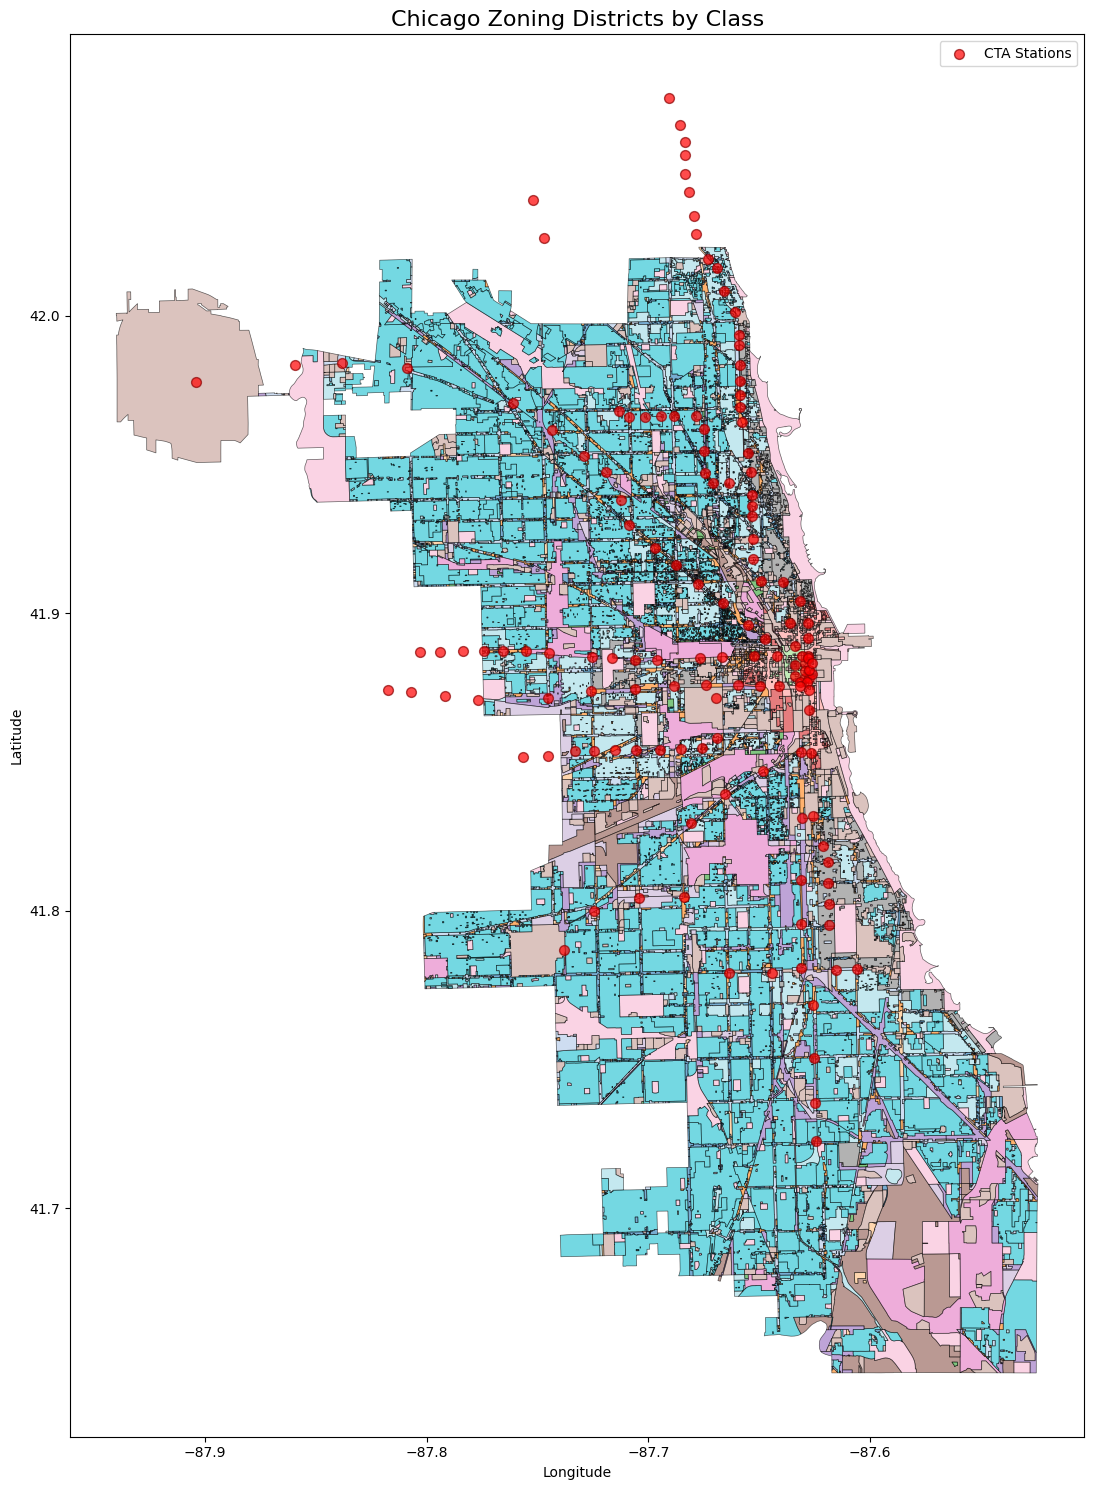

In [76]:
# Plot the zoning districts
fig, ax = plt.subplots(figsize=(15, 15))
zoning_gdf.plot(ax=ax, column='ZONE_TYPE', legend=True, cmap='tab20', alpha=0.6, edgecolor='black', linewidth=0.5)

# Add station locations
ax.scatter(si_aggregated['longitude'], si_aggregated['latitude'], 
           c='red', s=50, alpha=0.7, edgecolors='darkred', linewidth=1, 
           label='CTA Stations', zorder=5)

ax.set_title('Chicago Zoning Districts by Class', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [77]:
si_aggregated

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,41670,Conservatory,41.884904,-87.716523,1,0,0,1,0,0,0,0,0,0,1
140,41680,Oakton-Skokie,42.026243,-87.747221,1,0,0,0,0,0,1,0,0,1,0
141,41690,Cermak-McCormick Place,41.853115,-87.626402,1,0,0,1,0,0,0,0,0,1,0
142,41700,Washington/Wabash,41.883220,-87.626189,1,0,0,1,1,1,0,1,1,1,0


In [78]:
# Create a GeoDataFrame with station locations with shapes representing a 1 mile buffer around each station
si_gdf = gpd.GeoDataFrame(
    si_aggregated,
    geometry=gpd.points_from_xy(si_aggregated['longitude'], si_aggregated['latitude']),
    crs='EPSG:4326'
)

# Project to a projected CRS that uses meters (Chicago area: NAD83 / Illinois East)
si_gdf_projected = si_gdf.to_crs('EPSG:2790')

# Create 1-mile buffers (1 mile = 1609.34 meters)
feet_per_mile = 5280
meters_per_foot = 0.3048
meters_per_mile = feet_per_mile * meters_per_foot  # 1609.344 meters

si_gdf_projected['geometry_mile'] = si_gdf_projected.geometry.buffer(meters_per_mile)
si_gdf_projected['geometry_half_mile'] = si_gdf_projected.geometry.buffer(meters_per_mile / 2)

# WGS84 is EPSG:4326, where coordinates are in decimal degrees
# (x = longitude, y = latitude), not linear units like meters/feet.
si_gdf['geometry_mile'] = gpd.GeoSeries(
    si_gdf_projected['geometry_mile'], crs=si_gdf_projected.crs
).to_crs(si_gdf.crs)

si_gdf['geometry_half_mile'] = gpd.GeoSeries(
    si_gdf_projected['geometry_half_mile'], crs=si_gdf_projected.crs
).to_crs(si_gdf.crs)
display(si_gdf.head())

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W,geometry,geometry_mile,geometry_half_mile
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1,POINT (-87.77681 41.87085),"POLYGON ((-87.75743 41.87076, -87.75753 41.869...","POLYGON ((-87.76712 41.8708, -87.76717 41.8700..."
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1,POINT (-87.80318 41.88685),"POLYGON ((-87.78379 41.88676, -87.78389 41.885...","POLYGON ((-87.79348 41.8868, -87.79353 41.8860..."
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1,POINT (-87.7254 41.88541),"POLYGON ((-87.70601 41.88531, -87.70612 41.883...","POLYGON ((-87.71571 41.88536, -87.71576 41.884..."
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0,POINT (-87.63374 41.87872),"POLYGON ((-87.61435 41.8786, -87.61446 41.8771...","POLYGON ((-87.62405 41.87866, -87.6241 41.8779..."
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0,POINT (-87.68354 42.04771),"POLYGON ((-87.6641 42.0476, -87.66421 42.04618...","POLYGON ((-87.67382 42.04765, -87.67388 42.046..."


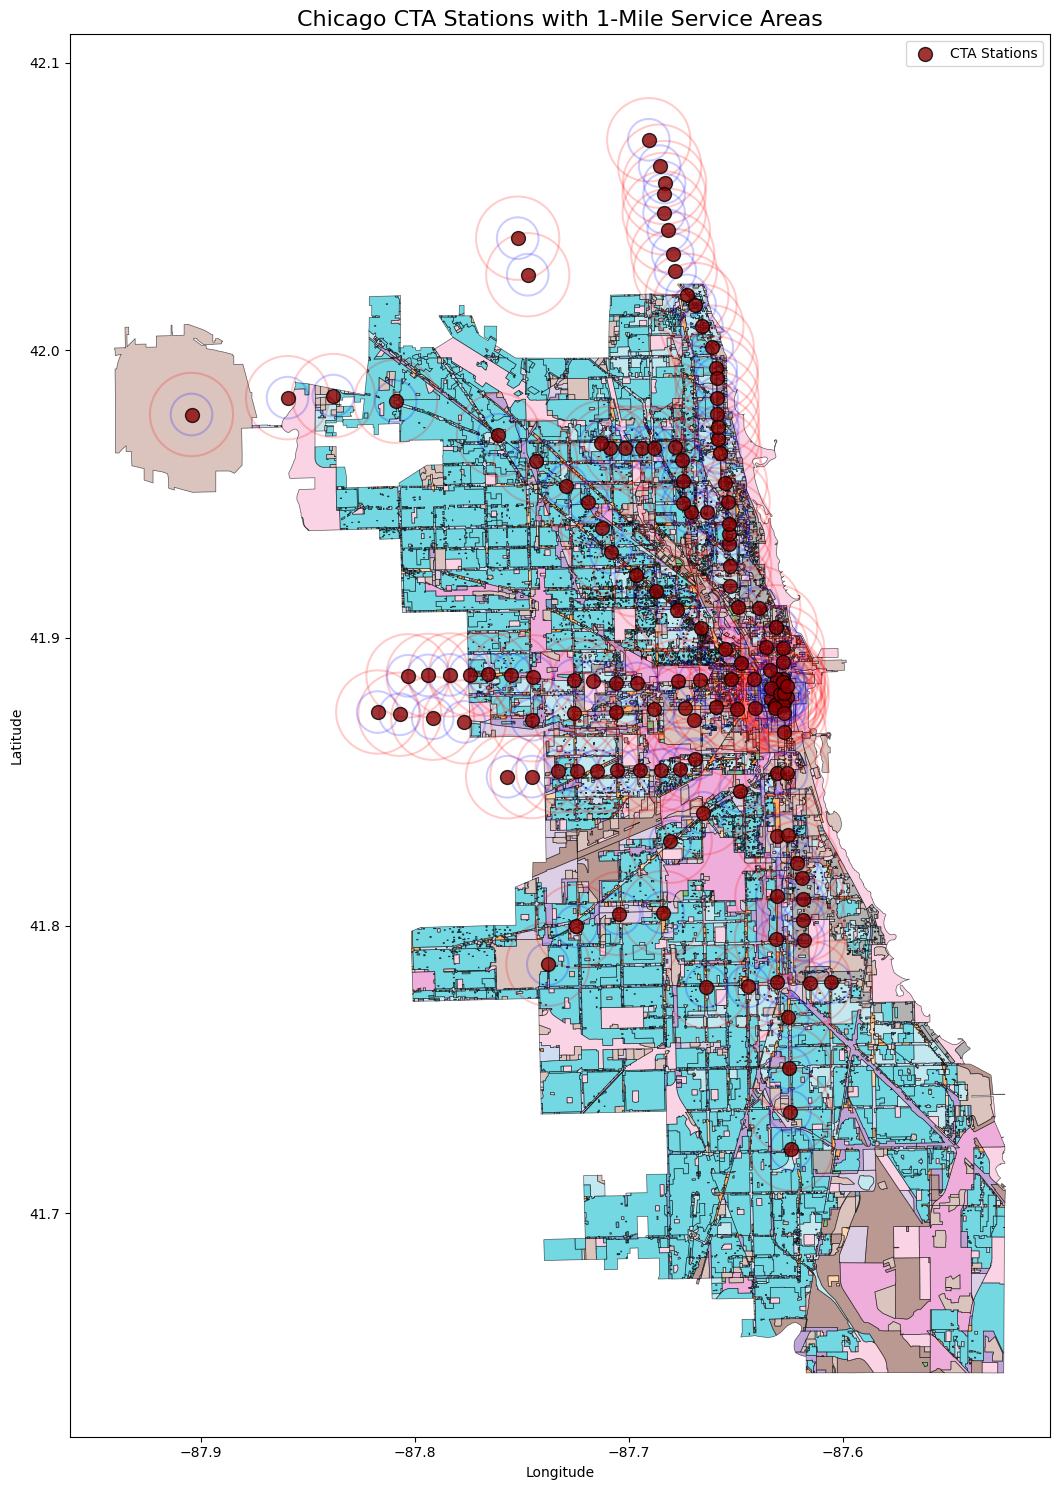

In [79]:
fig, ax = plt.subplots(figsize=(15, 15))
zoning_gdf.plot(ax=ax, column='ZONE_TYPE', legend=True, cmap='tab20', alpha=0.6, edgecolor='black', linewidth=0.5)

# Plot station points
ax.scatter(si_gdf['longitude'], si_gdf['latitude'], 
           c='darkred', s=100, alpha=0.8, edgecolors='black', linewidth=1, 
           label='CTA Stations', zorder=5)

ax.set_title('Chicago CTA Stations with 1-Mile Service Areas', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()


si_gdf['geometry_mile'].plot(
    ax=ax,
    facecolor='none',
    edgecolor='red',
    alpha=0.2,
    linewidth=1.5,
    zorder=4
)

si_gdf['geometry_half_mile'].plot(
    ax=ax,
    facecolor='none',
    edgecolor='blue',
    alpha=0.2,
    linewidth=1.5,
    zorder=4
)

# ax.set_ylim(miny, maxy)
# minx, miny, maxx, maxy = zoning_gdf.total_bounds
# ax.set_xlim(minx, maxx)

plt.show()

In [80]:

for zone_class in zone_classes:
    zone_polygons = zoning_gdf[zoning_gdf['ZONE_TYPE'] == zone_class]['geometry']
    zone_class_column_name = zone_translation_column_dict[zone_class]

    mile_column_name = f"{zone_class_column_name}_within_mile"
    half_mile_column_name = f"{zone_class_column_name}_within_half_mile"
    
    si_gdf[mile_column_name] = si_gdf['geometry_mile'].apply(lambda x: zone_polygons.intersects(x).any()).astype(int)
    si_gdf[half_mile_column_name] = si_gdf['geometry_half_mile'].apply(lambda x: zone_polygons.intersects(x).any()).astype(int)

si_gdf.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,...,regional_or_community_park_within_mile,regional_or_community_park_within_half_mile,residential_multi_unit_district_within_mile,residential_multi_unit_district_within_half_mile,residential_single_unit_district_within_mile,residential_single_unit_district_within_half_mile,residential_two_flat_townhouse_and_multi_unit_district_within_mile,residential_two_flat_townhouse_and_multi_unit_district_within_half_mile,transportation_district_within_mile,transportation_district_within_half_mile
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,...,1,1,0,0,1,1,1,1,0,0
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,...,1,1,0,0,1,1,1,1,0,0
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,...,1,0,0,0,0,0,1,0,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [81]:
ridership_with_zoning = pd.merge(station_ridership, si_gdf.drop(columns=['geometry', 'geometry_mile', 'geometry_half_mile']), left_on='MAP_ID', right_on='MAP_ID', how='left')

ridership_with_zoning.head()

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,regional_or_community_park_within_mile,regional_or_community_park_within_half_mile,residential_multi_unit_district_within_mile,residential_multi_unit_district_within_half_mile,residential_single_unit_district_within_mile,residential_single_unit_district_within_half_mile,residential_two_flat_townhouse_and_multi_unit_district_within_mile,residential_two_flat_townhouse_and_multi_unit_district_within_half_mile,transportation_district_within_mile,transportation_district_within_half_mile
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [82]:
# Build a modeling dataset from ridership_with_zoning
model_df = ridership_with_zoning.copy()

# Keep core temporal/transit features + zoning proximity flags
base_features = [
    'days_since_2000', 'post_shutdown', 'season_Spring', 'season_Summer', 'season_Winter', 'year', 'PRCP', 'TAVG', 'SNOW', 'SNWD', 'Fog_Ice_Fog', 'Blowing_Snow', "latitude_x", "longitude_x", 'ADA_x', 'RED_x', 'BLUE_x', 'G_x', 'BRN_x', 'P_x', 'Y_x', 'Pnk_x', 'O_x', 'N/S_x', 'E/W_x'
]
zoning_features = [c for c in model_df.columns if c.endswith('_mile') or c.endswith('_half_mile')]
feature_cols = [c for c in base_features if c in model_df.columns] + zoning_features

X = model_df[feature_cols].copy()
y = model_df['rides'].copy()

# Add daytype as dummy variables
daytype_dummies = pd.get_dummies(model_df['daytype'], prefix='daytype', drop_first=True, dtype=int)
X = pd.concat([X, daytype_dummies], axis=1)

# Convert boolean columns to int
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# Force all predictors/target to numeric for statsmodels compatibility
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Drop rows with any missing values in features/target
valid_mask = X.notna().all(axis=1) & y.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]

# Optional sampling for speed on very large dataset
sample_n = min(200_000, len(X))
sample_idx = X.sample(n=sample_n, random_state=42).index
#X = X.loc[sample_idx]
#y = y.loc[sample_idx]

In [83]:
X.head()

,days_since_2000,post_shutdown,season_Spring,season_Summer,season_Winter,year,PRCP,TAVG,SNOW,SNWD,...,residential_multi_unit_district_within_mile,residential_multi_unit_district_within_half_mile,residential_single_unit_district_within_mile,residential_single_unit_district_within_half_mile,residential_two_flat_townhouse_and_multi_unit_district_within_mile,residential_two_flat_townhouse_and_multi_unit_district_within_half_mile,transportation_district_within_mile,transportation_district_within_half_mile,daytype_U,daytype_W
0,6565,0,0,0,1,2017,0.00,38.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,1
1,6561,0,0,0,1,2017,0.01,42.0,0.0,0.0,...,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0,1
2,6545,0,0,0,1,2017,0.00,42.0,0.0,0.0,...,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0,0
3,6562,0,0,0,1,2017,0.00,43.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,1
4,6546,0,0,0,1,2017,0.00,43.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,0


In [84]:
# 1. Define your cutoff (approximate days from 2000 to end of 2023)
# 24 years * 365.25 days = 8766
#cutoff_value = 8766
cutoff_value = 25*365.25

# 2. Create the mask
train_mask = X['days_since_2000'] <= cutoff_value
test_mask = X['days_since_2000'] > cutoff_value

# 3. Split the data
X_train, X_test = X.loc[train_mask], X.loc[test_mask]
y_train, y_test = y.loc[train_mask], y.loc[test_mask]

print(f"Training rows: {len(X_train)} (Through 2023)")
print(f"Testing rows: {len(X_test)} (2024 onwards)")

Training rows: 839539 (Through 2023)
Testing rows: 47520 (2024 onwards)


In [85]:
#Fit OLS model
X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

ols_model = sm.OLS(y_train, X_train_const).fit()

# Predict and evaluate
y_pred = ols_model.predict(X_test_const)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R²:   {r2:.4f}")

# Full statistical summary
print(ols_model.summary())

RMSE: 1,411.08
MAE:  1,061.13
R²:   0.5517
                            OLS Regression Results                            
Dep. Variable:                  rides   R-squared:                       0.679
Model:                            OLS   Adj. R-squared:                  0.679
Method:                 Least Squares   F-statistic:                 2.730e+04
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:38:36   Log-Likelihood:            -7.4368e+06
No. Observations:              839539   AIC:                         1.487e+07
Df Residuals:                  839473   BIC:                         1.487e+07
Df Model:                          65                                         
Covariance Type:            nonrobust                                         
                                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

In [86]:
#Try decision tree
# Initialize and fit
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_dt = dt_model.predict(X_test)

print(f"Decision Tree RMSE: {mean_squared_error(y_test, y_pred_dt)**0.5:,.2f}")
print(f"Decision Tree R²:   {r2_score(y_test, y_pred_dt):.4f}")

Decision Tree RMSE: 826.03
Decision Tree R²:   0.8464


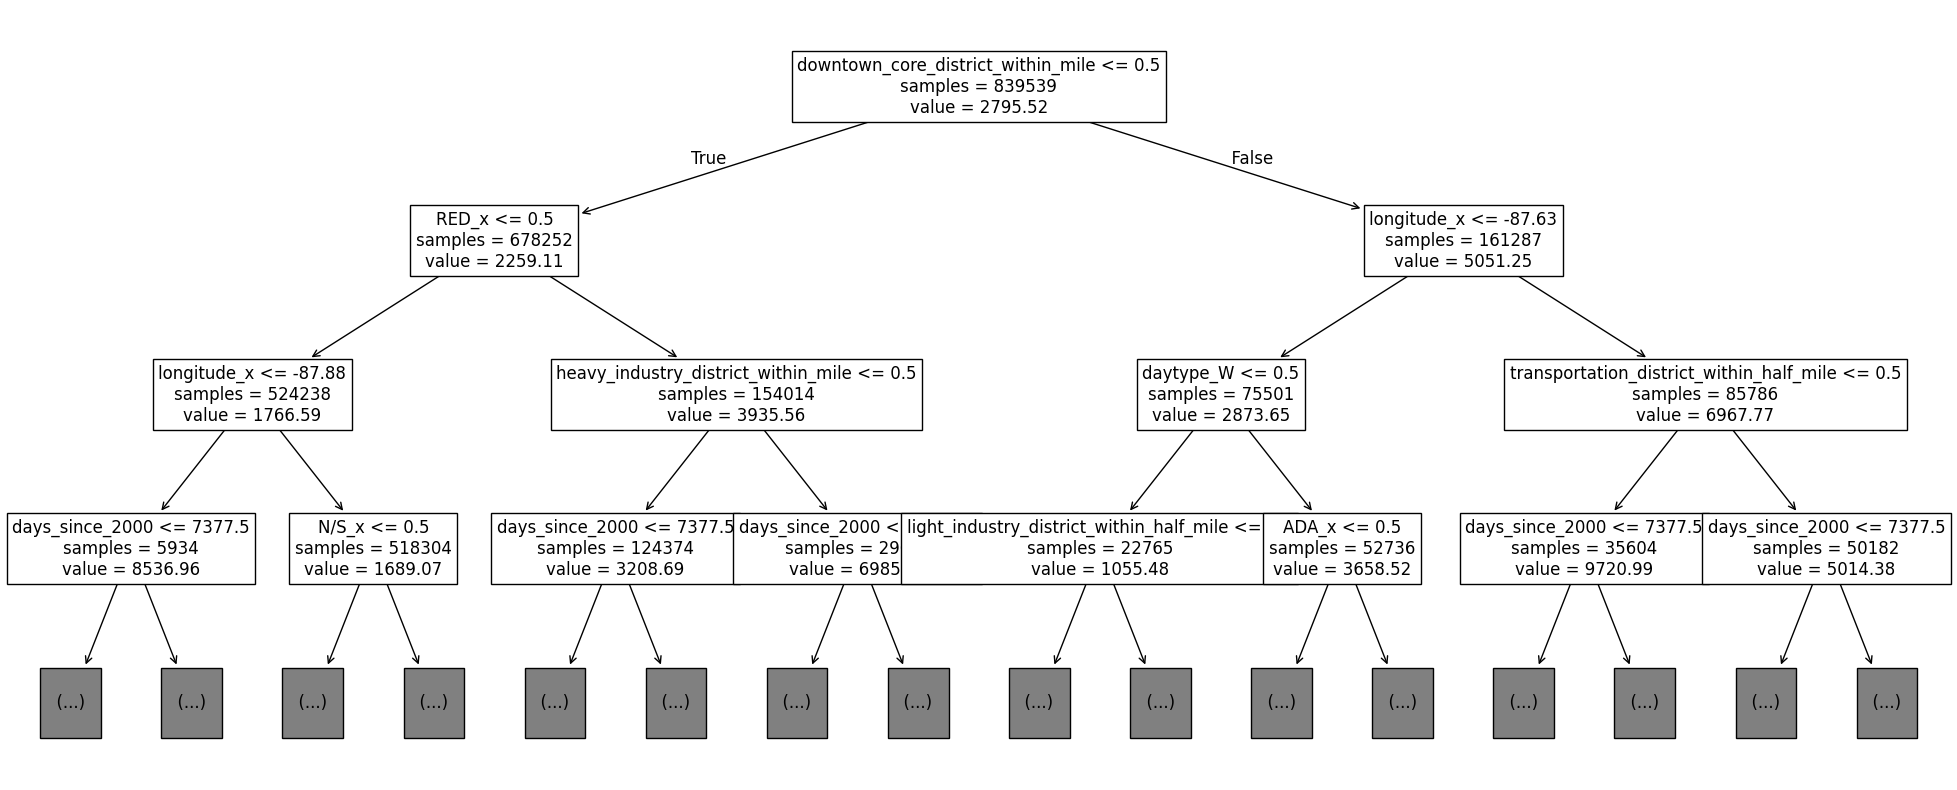

In [87]:
plt.figure(figsize=(25,10))
plot_tree(dt_model,
          feature_names=X_train.columns,
          max_depth=3,
          filled=False,        # Removes the orange background
          impurity=False,     # Removes the "squared_error" text to declutter
          fontsize=12,        # Increases text size
          precision=2)        # Rounds numbers to 2 decimals
plt.show()

Top Features:
                                      Feature  Importance
0                            days_since_2000    0.164032
13                               longitude_x    0.151500
37        downtown_core_district_within_mile    0.144879
66                                 daytype_W    0.109511
15                                     RED_x    0.087005
64  transportation_district_within_half_mile    0.067420
49       heavy_industry_district_within_mile    0.058557
14                                     ADA_x    0.028742
12                                latitude_x    0.028082
23                                     N/S_x    0.026585


Top Features:
                                      Feature  Importance
0                            days_since_2000    0.164032
13                               longitude_x    0.151500
37        downtown_core_district_within_mile    0.144879
66                                 daytype_W    0.109511
15                                     RED_x    0.087005
64  transportation_district_within_half_mile    0.067420
49       heavy_industry_district_within_mile    0.058557
14                                     ADA_x    0.028742
12                                latitude_x    0.028082
23                                     N/S_x    0.026585


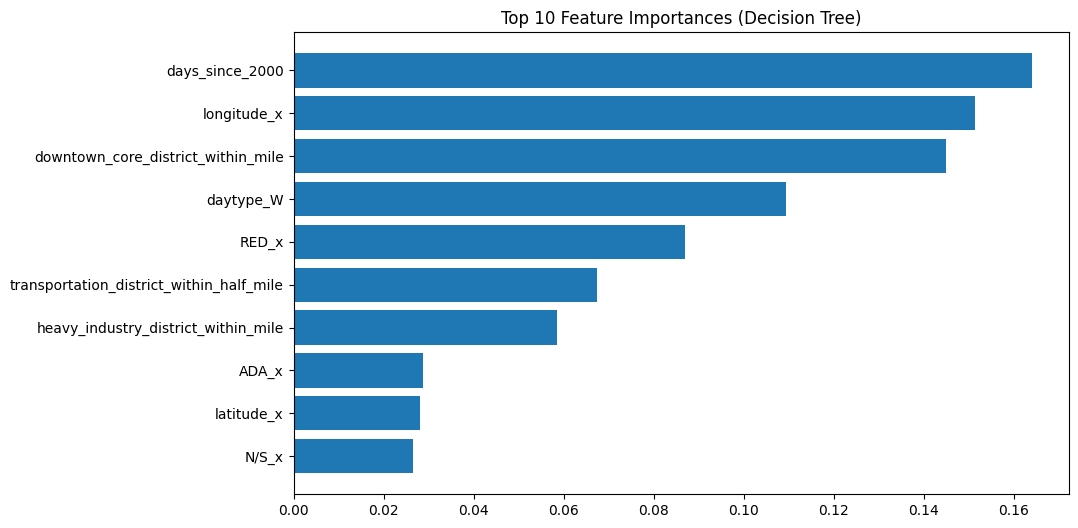

In [88]:
#Evaluate feature importance
importances = dt_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top Features:\n", feature_importance_df.head(10))

#Visualize results
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.show()

In [91]:
def ablation_test(list_feats):
    for feat in list_feats:
        X_train_ablated = X_train.drop(columns=[feat])
        X_test_ablated = X_test.drop(columns=[feat])

        dt_ablated = DecisionTreeRegressor(max_depth=10, random_state=42)
        dt_ablated.fit(X_train_ablated, y_train)
        y_pred_ablated = dt_ablated.predict(X_test_ablated)
        print(f"Ablated ({feat} removed) RMSE: {mean_squared_error(y_test, y_pred_ablated)**0.5:,.2f}")

ablation_test(['days_since_2000', 'longitude_x', 'downtown_core_district_within_mile', 'daytype_W', 'RED_x', 'transportation_district_within_half_mile',
               'heavy_industry_district_within_mile', 'latitude_x', 'ADA_x', 'BLUE_x'])

Ablated (days_since_2000 removed) RMSE: 798.95
Ablated (longitude_x removed) RMSE: 807.15
Ablated (downtown_core_district_within_mile removed) RMSE: 908.60
Ablated (daytype_W removed) RMSE: 860.34
Ablated (RED_x removed) RMSE: 966.07
Ablated (transportation_district_within_half_mile removed) RMSE: 825.40
Ablated (heavy_industry_district_within_mile removed) RMSE: 825.31
Ablated (latitude_x removed) RMSE: 832.71
Ablated (ADA_x removed) RMSE: 869.88
Ablated (BLUE_x removed) RMSE: 910.61


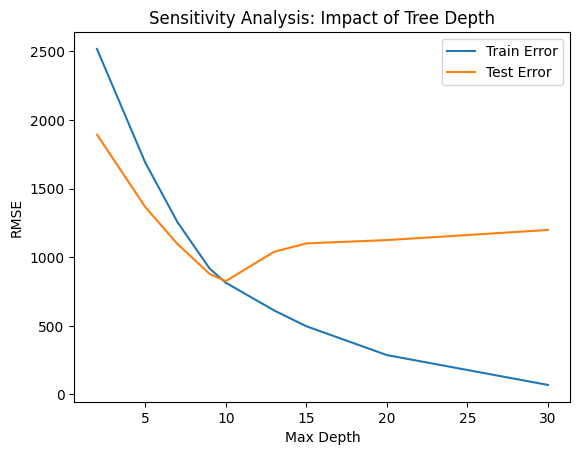

In [92]:
depths = [2, 5, 7, 9, 10, 13, 15, 20, 30]
train_errors = []
test_errors = []

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    # Calculate RMSE for both sets
    train_rmse = mean_squared_error(y_train, model.predict(X_train))**0.5
    test_rmse = mean_squared_error(y_test, model.predict(X_test))**0.5

    train_errors.append(train_rmse)
    test_errors.append(test_rmse)

plt.plot(depths, train_errors, label='Train Error')
plt.plot(depths, test_errors, label='Test Error')
plt.xlabel('Max Depth')
plt.ylabel('RMSE')
plt.title('Sensitivity Analysis: Impact of Tree Depth')
plt.legend()
plt.show()

In [93]:
# 1. Calculate errors and sort (same as before)
results = X_test.copy()
results['Actual'] = y_test
results['Predicted'] = y_pred_dt
results['Abs_Error'] = abs(results['Actual'] - results['Predicted'])

# 2. Get top 3 as a DataFrame
# We use .head(3) to keep it concise
top_failures_df = results.sort_values(by='Abs_Error', ascending=False).head(3)

# 3. Display the DataFrame
# If you are in a Jupyter Notebook, just typing the variable name prints a nice table
top_failures_df

,days_since_2000,post_shutdown,season_Spring,season_Summer,season_Winter,year,PRCP,TAVG,SNOW,SNWD,...,residential_single_unit_district_within_half_mile,residential_two_flat_townhouse_and_multi_unit_district_within_mile,residential_two_flat_townhouse_and_multi_unit_district_within_half_mile,transportation_district_within_mile,transportation_district_within_half_mile,daytype_U,daytype_W,Actual,Predicted,Abs_Error
1259743,9205,1,1,0,0,2025,0.31,62.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0,0,24425,6940.508516,17484.491484
1259898,9205,1,1,0,0,2025,0.31,62.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0,0,25011,8116.126521,16894.873479
1292447,9416,1,0,0,0,2025,0.00,59.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1,0,15472,1891.173254,13580.826746


In [94]:
#The biggest miss was on March 15, 2025 (9205 days after 2000) at Grand (Red Line) and Clark/Lake (Transfer Station), followed by October 12, 2025 (9416 days) at Cermak-Chinatown (Red Line).
#Likely due to St. Patrick's Day for the former and the Chicago Marathon for the latter

In [95]:
#Try random forest
# Initialize and fit
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)

print(f"Random Forest RMSE: {mean_squared_error(y_test, y_pred_rf)**0.5:,.2f}")
print(f"Random Forest R²:   {r2_score(y_test, y_pred_rf):.4f}")

Random Forest RMSE: 901.33
Random Forest R²:   0.8171


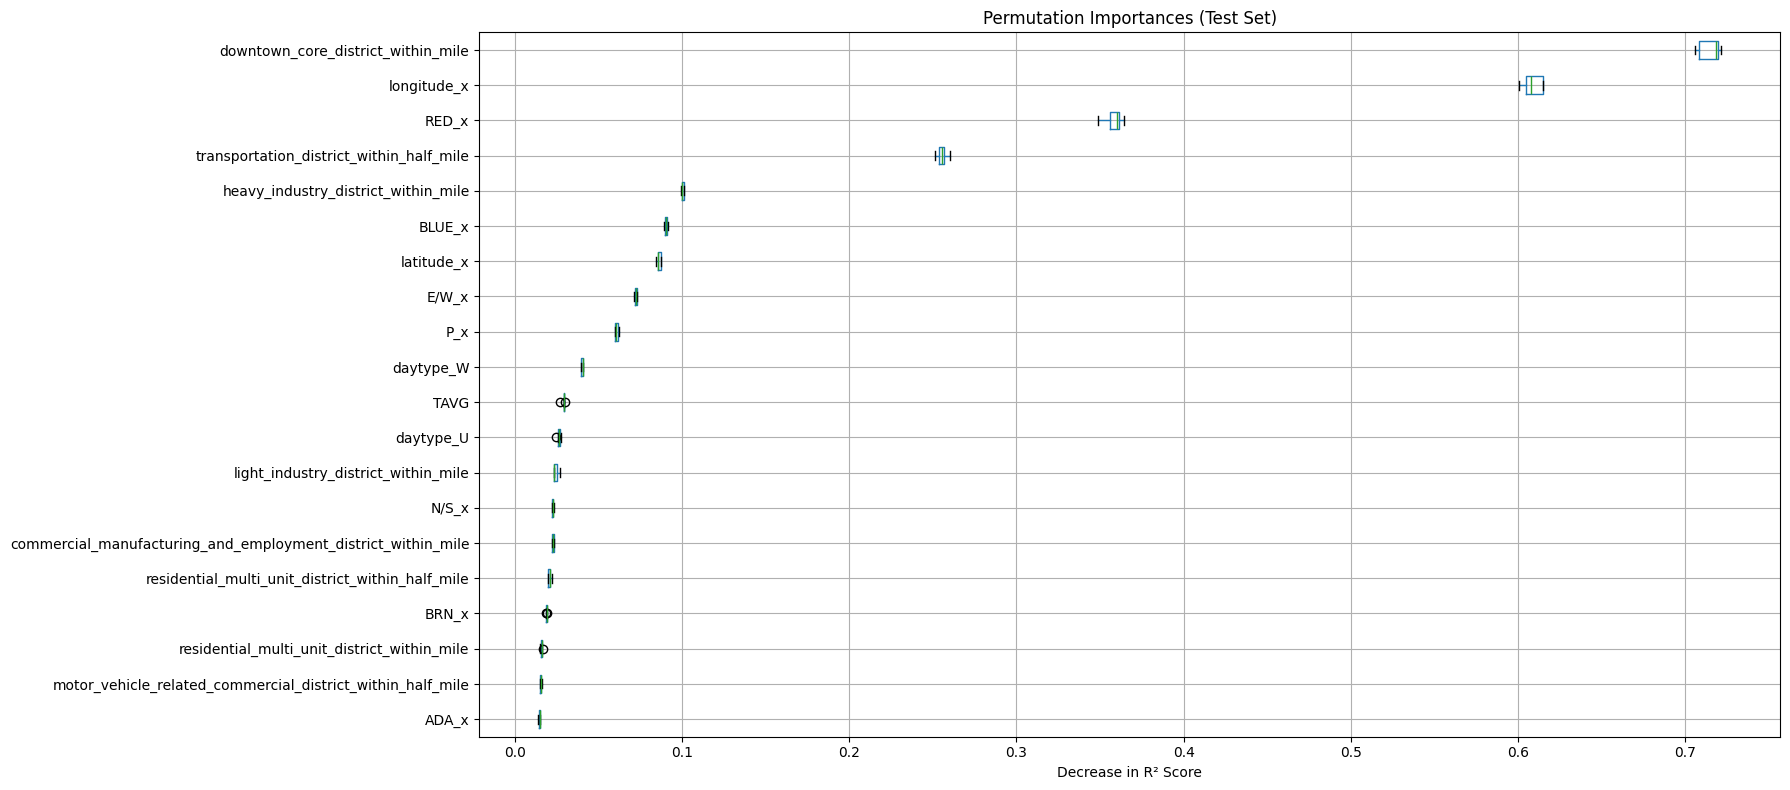

In [111]:
result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=5, random_state=42, n_jobs=-1
)

# Organize the results
perm_sorted_idx = result.importances_mean.argsort()
perm_df = pd.DataFrame(
    result.importances[perm_sorted_idx].T,
    columns=X.columns[perm_sorted_idx]
)

# Plotting the result
plt.figure(figsize=(18, 8))
perm_df.iloc[:, -20:].boxplot(vert=False, manage_ticks=True)
plt.title("Permutation Importances (Test Set)")
plt.xlabel("Decrease in R² Score")
plt.tight_layout()
plt.show()

In [97]:
#Trying because Huber Regressor treats small errors as squared (like linear regression) but treats large errors (outliers) as linear so it's more robust to outliers
# 1. Create the Robust Pipeline
# epsilon: A smaller epsilon (closer to 1.0) makes it MORE robust to outliers.
# The default is 1.35, which is usually a good balance.
huber_pipeline = make_pipeline(
    StandardScaler(),
    HuberRegressor(epsilon=1.35, max_iter=1000)
)

# 2. Train the model
huber_pipeline.fit(X_train, y_train)

# 3. Predict
y_pred_huber = huber_pipeline.predict(X_test)

# 4. Evaluate
print(f"Huber RMSE: {mean_squared_error(y_test, y_pred_huber)**0.5:,.2f}")
print(f"Huber R²:   {r2_score(y_test, y_pred_huber):.4f}")

Huber RMSE: 1,291.29
Huber R²:   0.6246


In [98]:
# PCA on ridership_with_zoning (with fallback to ridershipo_with_zoning if that exists)
pca_source_df = ridership_with_zoning.copy()

# Drop non-feature columns that are not directly usable
pca_features = pca_source_df.drop(columns=['date', 'rides'], errors='ignore')

# Encode categorical fields
cat_cols = pca_features.select_dtypes(include=['object', 'string', 'category']).columns
pca_features = pd.get_dummies(pca_features, columns=cat_cols, drop_first=True, dtype=int)

# Convert bools and coerce to numeric
bool_cols = pca_features.select_dtypes(include='bool').columns
pca_features[bool_cols] = pca_features[bool_cols].astype(int)
pca_features = pca_features.apply(pd.to_numeric, errors='coerce').dropna()

# Optional sampling for speed
sample_n = min(200_000, len(pca_features))
pca_features = pca_features.sample(n=sample_n)

# Standardize then fit PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_features)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)
n95 = np.argmax(cum_explained >= 0.95) + 1

print(f"Rows used for PCA: {len(pca_features):,}")
print(f"Original feature count: {pca_features.shape[1]:,}")
print(f"Components to explain >=95% variance: {n95}")
print(f"First 10 explained variance ratios:\n{explained[:10]}")

# PCA scores dataframe (first n95 components)
si_pca_scores = pd.DataFrame(
    X_pca[:, :n95],
    columns=[f'PC{i+1}' for i in range(n95)],
    index=pca_features.index
)
display(si_pca_scores.head())


Rows used for PCA: 200,000
Original feature count: 458
Components to explain >=95% variance: 139
First 10 explained variance ratios:
[0.041193   0.02796789 0.02076383 0.01514147 0.01373057 0.01186466
 0.0108974  0.01082379 0.01055791 0.0105188 ]


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC130,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138,PC139
843827,3.569211,-0.857902,3.637666,2.407310,0.288760,1.564543,1.216441,0.890277,-1.582954,-0.815203,...,0.059665,0.743344,1.836535,-1.249892,0.953067,-2.400090,-1.141359,0.029351,1.294215,-1.454569
477756,1.432233,3.732084,-3.068766,-2.259077,0.094740,3.006873,-2.371087,-1.230230,-1.742611,-2.177121,...,0.081510,0.049707,-0.027289,-0.019994,0.062559,-0.008974,0.223909,0.134258,-0.022848,-0.284845
914751,-6.529468,-5.137691,4.736799,-1.488245,-1.974312,-0.942124,3.365898,-0.739550,-1.592639,-2.251692,...,0.706576,0.580479,0.698027,-3.556661,-4.730046,0.468656,0.400325,-1.793216,-2.325636,-1.448036
1068976,2.841623,-0.105792,3.052569,1.019735,-0.313129,0.798289,-0.238165,0.062540,-2.030757,-0.640259,...,0.105041,0.072806,0.133299,-0.141067,0.024937,-0.023056,0.175021,-0.036903,0.066858,-0.097256
1250759,-6.282898,8.551561,2.415562,3.800332,0.470594,-4.643083,0.000097,-3.489573,-1.159162,3.410418,...,-0.085574,-0.029297,-0.015842,0.214978,0.047986,0.253534,-0.666417,-0.109995,-0.149622,0.206965


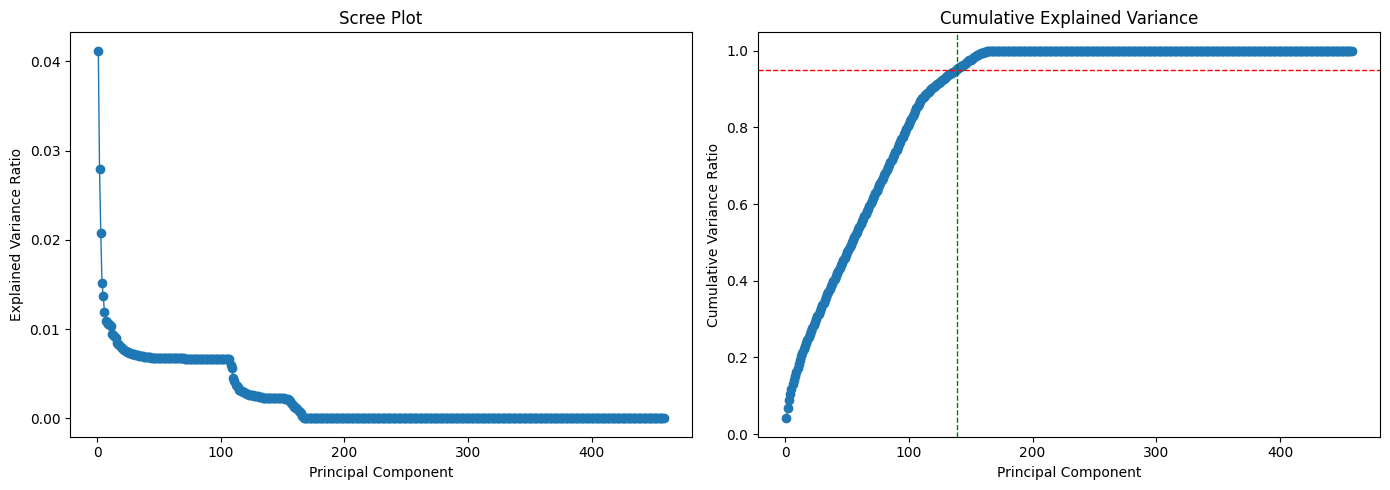

In [99]:

# Scree + cumulative variance plots
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(1, len(explained) + 1), explained, marker='o', linewidth=1)
ax[0].set_title('Scree Plot')
ax[0].set_xlabel('Principal Component')
ax[0].set_ylabel('Explained Variance Ratio')

ax[1].plot(range(1, len(cum_explained) + 1), cum_explained, marker='o', linewidth=1)
ax[1].axhline(0.95, color='red', linestyle='--', linewidth=1)
ax[1].axvline(n95, color='green', linestyle='--', linewidth=1)
ax[1].set_title('Cumulative Explained Variance')
ax[1].set_xlabel('Principal Component')
ax[1].set_ylabel('Cumulative Variance Ratio')

plt.tight_layout()
plt.show()

In [116]:
feature_names = pca_features.columns

# Loadings matrix: rows=original features, cols=PCs
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
# Remove station name features from loadings to declutter interpretation
station_name_mask = (
    loadings.index.str.startswith("stationname_") |
    loadings.index.str.startswith("STATION_NAME_")
)
loadings = loadings.loc[~station_name_mask].copy()
# Show top contributors for first 3 PCs
for pc in ["PC1", "PC2", "PC3"]:
    print(f"\nTop + contributors to {pc}")
    print(loadings[pc].sort_values(ascending=False).head(10))
    print(f"\nTop - contributors to {pc}")
    print(loadings[pc].sort_values(ascending=True).head(10))

# Contribution strength (absolute loading) for PC1/PC2/PC3
pc1_contrib = loadings[["PC1",]].abs().sort_values("PC1", ascending=False)
pc2_contrib = loadings[["PC2",]].abs().sort_values("PC2", ascending=False)
pc3_contrib = loadings[["PC3",]].abs().sort_values("PC3", ascending=False)
display(pc1_contrib.head(20))
display(pc2_contrib.head(20))
display(pc3_contrib.head(20))


Top + contributors to PC1
community_shopping_district_within_half_mile                               0.215355
residential_two_flat_townhouse_and_multi_unit_district_within_half_mile    0.211420
neighborhood_commercial_district_within_half_mile                          0.209086
neighborhood_shopping_district_within_half_mile                            0.208008
neighborhood_shopping_district_within_mile                                 0.205395
neighborhood_mixed_use_district_within_mile                                0.203529
residential_two_flat_townhouse_and_multi_unit_district_within_mile         0.199889
residential_single_unit_district_within_mile                               0.194054
limited_manufacturing_business_park_district_within_mile                   0.193336
motor_vehicle_related_commercial_district_within_mile                      0.188730
Name: PC1, dtype: float64

Top - contributors to PC1
downtown_core_district_within_half_mile        -0.108534
P_x                    


Top + contributors to PC1
community_shopping_district_within_half_mile                               0.215355
residential_two_flat_townhouse_and_multi_unit_district_within_half_mile    0.211420
neighborhood_commercial_district_within_half_mile                          0.209086
neighborhood_shopping_district_within_half_mile                            0.208008
neighborhood_shopping_district_within_mile                                 0.205395
neighborhood_mixed_use_district_within_mile                                0.203529
residential_two_flat_townhouse_and_multi_unit_district_within_mile         0.199889
residential_single_unit_district_within_mile                               0.194054
limited_manufacturing_business_park_district_within_mile                   0.193336
motor_vehicle_related_commercial_district_within_mile                      0.188730
Name: PC1, dtype: float64

Top - contributors to PC1
downtown_core_district_within_half_mile        -0.108534
P_x                    

,PC1
community_shopping_district_within_half_mile,0.215355
residential_two_flat_townhouse_and_multi_unit_district_within_half_mile,0.211420
neighborhood_commercial_district_within_half_mile,0.209086
neighborhood_shopping_district_within_half_mile,0.208008
neighborhood_shopping_district_within_mile,0.205395
neighborhood_mixed_use_district_within_mile,0.203529
residential_two_flat_townhouse_and_multi_unit_district_within_mile,0.199889
residential_single_unit_district_within_mile,0.194054
limited_manufacturing_business_park_district_within_mile,0.193336
motor_vehicle_related_commercial_district_within_mile,0.188730


,PC2
downtown_mixed_use_district_within_mile,0.240538
downtown_residential_district_within_mile,0.239415
downtown_service_district_within_mile,0.239326
downtown_mixed_use_district_within_half_mile,0.238294
downtown_core_district_within_mile,0.228069
downtown_core_district_within_half_mile,0.206048
downtown_service_district_within_half_mile,0.195484
downtown_residential_district_within_half_mile,0.195350
longitude_x,0.185474
longitude_y,0.185474


,PC3
E/W_x,0.296283
E/W_y,0.296283
N/S_y,0.293541
N/S_x,0.293541
RED_y,0.197573
RED_x,0.197573
Pnk_x,0.147968
Pnk_y,0.147968
G_x,0.140783
G_y,0.140783


In [101]:
def get_top_contributors(loadings_df, pc_count, top_n=10):
    top_features = set()
    for i in range(1, pc_count + 1):
        pc_col = f"PC{i}"
        top_features.update(loadings_df[pc_col].abs().sort_values(ascending=False).head(top_n).index)
    return list(top_features)

result = get_top_contributors(loadings, pc_count=3, top_n=10)
result

['neighborhood_mixed_use_district_within_mile',
 'G_y',
 'downtown_mixed_use_district_within_mile',
 'downtown_core_district_within_mile',
 'limited_manufacturing_business_park_district_within_mile',
 'E/W_y',
 'motor_vehicle_related_commercial_district_within_mile',
 'E/W_x',
 'downtown_service_district_within_mile',
 'longitude_x',
 'RED_y',
 'N/S_x',
 'downtown_core_district_within_half_mile',
 'Pnk_x',
 'Pnk_y',
 'residential_two_flat_townhouse_and_multi_unit_district_within_mile',
 'neighborhood_shopping_district_within_mile',
 'downtown_service_district_within_half_mile',
 'neighborhood_shopping_district_within_half_mile',
 'downtown_residential_district_within_mile',
 'community_shopping_district_within_half_mile',
 'residential_two_flat_townhouse_and_multi_unit_district_within_half_mile',
 'longitude_y',
 'residential_single_unit_district_within_mile',
 'downtown_residential_district_within_half_mile',
 'RED_x',
 'G_x',
 'downtown_mixed_use_district_within_half_mile',
 'neighbo

In [102]:
# Add PCA columns to ridership_with_zoning
# Prepare features for PCA (same process as before)
pca_prep_df = ridership_with_zoning.copy()
cat_cols_pca = pca_prep_df.select_dtypes(include=['object', 'string', 'category']).columns
pca_prep_df = pd.get_dummies(pca_prep_df, columns=cat_cols_pca, drop_first=True, dtype=int)

# Convert bools to int and coerce to numeric
bool_cols_pca = pca_prep_df.select_dtypes(include='bool').columns
pca_prep_df[bool_cols_pca] = pca_prep_df[bool_cols_pca].astype(int)
pca_prep_df = pca_prep_df.apply(pd.to_numeric, errors='coerce')

# Drop rows with any NaN values for PCA fitting
pca_prep_df_clean = pca_prep_df.dropna()

# Standardize and fit PCA
scaler_final = StandardScaler()
X_scaled_final = scaler_final.fit_transform(pca_prep_df_clean)

pca_final = PCA()
X_pca_final = pca_final.fit_transform(X_scaled_final)

# Use 95% variance threshold
cum_var_final = np.cumsum(pca_final.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var_final >= 0.95) + 1

print(f"Number of components needed for 95% variance: {n_components_95}")
print(f"Total rows used for PCA: {len(pca_prep_df_clean):,}")

# Create dataframe with PC columns
pca_columns_df = pd.DataFrame(
    X_pca_final[:, :n_components_95],
    columns=[f'PC{i+1}' for i in range(n_components_95)],
    index=pca_prep_df_clean.index
)

# Add PCA columns to ridership_with_zoning (aligned by index)
ridership_with_zoning_pca = ridership_with_zoning.copy()
ridership_with_zoning_pca = ridership_with_zoning_pca.loc[pca_columns_df.index].copy()
ridership_with_zoning_pca = pd.concat([ridership_with_zoning_pca.reset_index(drop=True), 
                                        pca_columns_df.reset_index(drop=True)], axis=1)

print(f"\nOriginal ridership_with_zoning shape: {ridership_with_zoning.shape}")
print(f"ridership_with_zoning_pca shape: {ridership_with_zoning_pca.shape}")
print(f"New PC columns: {list(ridership_with_zoning_pca.columns[-n_components_95:])}")

display(ridership_with_zoning_pca.head())

Number of components needed for 95% variance: 139
Total rows used for PCA: 886,339

Original ridership_with_zoning shape: (1298399, 98)
ridership_with_zoning_pca shape: (886339, 237)
New PC columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37', 'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46', 'PC47', 'PC48', 'PC49', 'PC50', 'PC51', 'PC52', 'PC53', 'PC54', 'PC55', 'PC56', 'PC57', 'PC58', 'PC59', 'PC60', 'PC61', 'PC62', 'PC63', 'PC64', 'PC65', 'PC66', 'PC67', 'PC68', 'PC69', 'PC70', 'PC71', 'PC72', 'PC73', 'PC74', 'PC75', 'PC76', 'PC77', 'PC78', 'PC79', 'PC80', 'PC81', 'PC82', 'PC83', 'PC84', 'PC85', 'PC86', 'PC87', 'PC88', 'PC89', 'PC90', 'PC91', 'PC92', 'PC93', 'PC94', 'PC95', 'PC96', 'PC97', 'PC98', 'PC99', 'PC100', 'PC101',

Number of components needed for 95% variance: 139
Total rows used for PCA: 886,339

Original ridership_with_zoning shape: (1298399, 98)
ridership_with_zoning_pca shape: (886339, 237)
New PC columns: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'PC26', 'PC27', 'PC28', 'PC29', 'PC30', 'PC31', 'PC32', 'PC33', 'PC34', 'PC35', 'PC36', 'PC37', 'PC38', 'PC39', 'PC40', 'PC41', 'PC42', 'PC43', 'PC44', 'PC45', 'PC46', 'PC47', 'PC48', 'PC49', 'PC50', 'PC51', 'PC52', 'PC53', 'PC54', 'PC55', 'PC56', 'PC57', 'PC58', 'PC59', 'PC60', 'PC61', 'PC62', 'PC63', 'PC64', 'PC65', 'PC66', 'PC67', 'PC68', 'PC69', 'PC70', 'PC71', 'PC72', 'PC73', 'PC74', 'PC75', 'PC76', 'PC77', 'PC78', 'PC79', 'PC80', 'PC81', 'PC82', 'PC83', 'PC84', 'PC85', 'PC86', 'PC87', 'PC88', 'PC89', 'PC90', 'PC91', 'PC92', 'PC93', 'PC94', 'PC95', 'PC96', 'PC97', 'PC98', 'PC99', 'PC100', 'PC101',

,station_id,stationname,date,daytype,rides,AWND,PRCP,SNOW,SNWD,TAVG,...,PC130,PC131,PC132,PC133,PC134,PC135,PC136,PC137,PC138,PC139
0,41280,Jefferson Park,2017-12-22,W,6104,6.93,0.00,0.0,0.0,38.0,...,-0.058341,0.044854,0.045051,0.062382,0.062135,-0.017483,-0.015483,-0.053225,0.033216,-0.075408
1,41000,Cermak-Chinatown,2017-12-18,W,3636,11.41,0.01,0.0,0.0,42.0,...,0.059461,0.107457,-0.071441,-0.047151,-0.036417,-0.097431,-0.027060,0.493242,-0.049550,0.100211
2,40280,Central-Lake,2017-12-02,A,1270,4.25,0.00,0.0,0.0,42.0,...,1.212646,-0.026231,-1.812984,-0.389765,2.417917,1.761572,1.294842,-0.337503,0.540376,1.287686
3,40140,Dempster-Skokie,2017-12-19,W,1759,12.08,0.00,0.0,0.0,43.0,...,-0.029598,-0.052719,-0.024898,-0.155619,0.180264,0.056533,-0.049710,0.738490,-0.046170,-0.049044
4,40690,Dempster,2017-12-03,U,499,6.26,0.00,0.0,0.0,43.0,...,0.027610,-0.044473,-0.094395,-0.070587,0.110280,0.132648,0.030458,-0.127980,0.064995,-0.042988


In [103]:
def get_pc_cols(n):
    return [f"PC{i+1}" for i in range(n)]

# Build PCA-only modeling frame
pc_cols = sorted(
    [c for c in ridership_with_zoning_pca.columns if re.fullmatch(r"PC\d+", c)],
    key=lambda x: int(x[2:])
)

pc_model_df = ridership_with_zoning_pca[['days_since_2000', 'rides'] + pc_cols].copy()
pc_model_df = pc_model_df.apply(pd.to_numeric, errors='coerce').dropna()

X_pc = pc_model_df[['days_since_2000'] + pc_cols]
y_pc = pc_model_df['rides']

# Time-based split (reuse existing cutoff if present)
cutoff_value_pc = cutoff_value if 'cutoff_value' in globals() else 25 * 365.25
train_mask_pc = X_pc['days_since_2000'] <= cutoff_value_pc
test_mask_pc = X_pc['days_since_2000'] > cutoff_value_pc

X_train_pc, X_test_pc = X_pc.loc[train_mask_pc], X_pc.loc[test_mask_pc]
y_train_pc, y_test_pc = y_pc.loc[train_mask_pc], y_pc.loc[test_mask_pc]

print(f"PC train rows: {len(X_train_pc)}")
print(f"PC test rows:  {len(X_test_pc)}")
print(f"Available PC columns: {len(pc_cols)}")

# Evaluate different numbers of PCs
results = []
for count in range(1,10):
    cols = get_pc_cols(count)
    X_train_subset = X_train_pc[cols]
    X_test_subset = X_test_pc[cols]

    model = DecisionTreeRegressor(max_depth=10)
    model.fit(X_train_subset, y_train_pc)
    y_pred_subset = model.predict(X_test_subset)

    rmse_subset = mean_squared_error(y_test_pc, y_pred_subset) ** 0.5
    r2_subset = r2_score(y_test_pc, y_pred_subset)
    results.append((count, rmse_subset, r2_subset))
# Display results
results_df = pd.DataFrame(results, columns=["PC Count", "RMSE", "R2"])
print(results_df)

PC train rows: 839539
PC test rows:  46800
Available PC columns: 139
   PC Count         RMSE        R2
0         1  1473.231182  0.508498
1         2  1077.612833  0.737028
2         3   765.164093  0.867416
3         4   913.065779  0.811206
4         5   861.629575  0.831878
5         6  1027.242314  0.761038
6         7   958.566917  0.791921
7         8   956.366555  0.792875
8         9   956.395913  0.792863


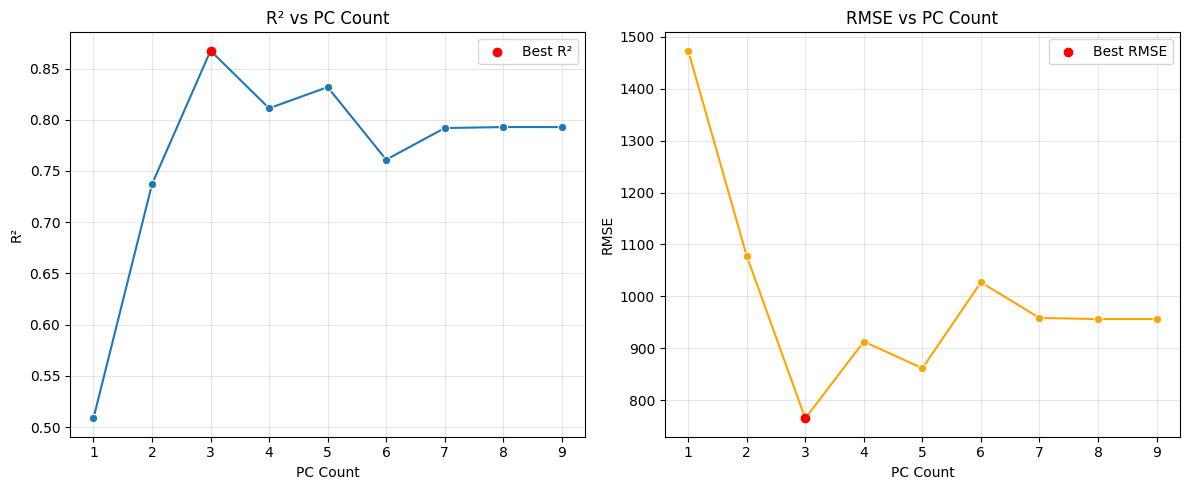

Best by R²   -> PC Count: 3, R²: 0.8674
Best by RMSE -> PC Count: 3, RMSE: 765.16


In [117]:
# Dual plots: R² and RMSE vs PC Count
if 'results_df' in globals() and {'PC Count', 'RMSE', 'R2'}.issubset(results_df.columns):
    plot_df = results_df.copy()
elif 'results' in globals():
    # Fallback if tuple-list exists: (PC Count, RMSE, R2)
    plot_df = pd.DataFrame(results, columns=['PC Count', 'RMSE', 'R2'])
else:
    raise ValueError("No PCA evaluation results found. Run the PCA model comparison cell first.")

plot_df = plot_df.sort_values('PC Count').reset_index(drop=True)

best_r2_idx = plot_df['R2'].idxmax()
best_rmse_idx = plot_df['RMSE'].idxmin()

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# R² plot
sns.lineplot(data=plot_df, x='PC Count', y='R2', marker='o', ax=axes[0])
axes[0].scatter(
    plot_df.loc[best_r2_idx, 'PC Count'],
    plot_df.loc[best_r2_idx, 'R2'],
    color='red',
    zorder=5,
    label='Best R²'
)
axes[0].set_title('R² vs PC Count')
axes[0].set_xlabel('PC Count')
axes[0].set_ylabel('R²')
axes[0].grid(alpha=0.3)
axes[0].legend()

# RMSE plot
sns.lineplot(data=plot_df, x='PC Count', y='RMSE', marker='o', ax=axes[1], color='orange')
axes[1].scatter(
    plot_df.loc[best_rmse_idx, 'PC Count'],
    plot_df.loc[best_rmse_idx, 'RMSE'],
    color='red',
    zorder=5,
    label='Best RMSE'
)
axes[1].set_title('RMSE vs PC Count')
axes[1].set_xlabel('PC Count')
axes[1].set_ylabel('RMSE')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best by R²   -> PC Count: {int(plot_df.loc[best_r2_idx, 'PC Count'])}, R²: {plot_df.loc[best_r2_idx, 'R2']:.4f}")
print(f"Best by RMSE -> PC Count: {int(plot_df.loc[best_rmse_idx, 'PC Count'])}, RMSE: {plot_df.loc[best_rmse_idx, 'RMSE']:.2f}")

By using principal components to predict ridership, performance seemed to peak using 4 principal components. Let's see if we can use the 3 principal components to feature engineer a lighter model that uses the top contributing features for all 4 principal coompents

In [113]:
plot_data = []
light_ridership_df = ridership_with_zoning.copy()

# print(ridership_with_zoning.columns)

# Iterate through different numbers of top features to evaluate model performance
for top_features_count in range(10, 100, 10):
    top_features = get_top_contributors(loadings, pc_count=3, top_n=top_features_count)
    
    light_ridership_df = ridership_with_zoning.copy()
    cat_cols = light_ridership_df.select_dtypes(include=['string', 'category']).columns.tolist()
    light_ridership_df = pd.get_dummies(light_ridership_df, columns=cat_cols, drop_first=True, dtype=int)
    light_ridership_df = light_ridership_df[top_features + ['rides']].dropna()
    
    X_light = light_ridership_df.drop(columns=['rides'])
    y_light = light_ridership_df['rides']
    X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_light, y_light, test_size=0.2, random_state=42)
    model_l = DecisionTreeRegressor(max_depth=15)
    model_l.fit(X_train_l, y_train_l)
    y_pred_l = model_l.predict(X_test_l)
    rmse_l = mean_squared_error(y_test_l, y_pred_l)**0.5
    r2_l = r2_score(y_test_l, y_pred_l)
    print(f"PCs: 3, Top N: {top_features_count} => RMSE: {rmse_l:,.2f}, R²: {r2_l:.4f}")
    plot_data.append({
        'Top_features': top_features_count,
        'RMSE': rmse_l,
        'R2': r2_l
    })

PCs: 3, Top N: 10 => RMSE: 1,783.36, R²: 0.6523
PCs: 3, Top N: 20 => RMSE: 1,778.75, R²: 0.6541
PCs: 3, Top N: 30 => RMSE: 1,778.66, R²: 0.6541
PCs: 3, Top N: 40 => RMSE: 1,778.70, R²: 0.6541
PCs: 3, Top N: 50 => RMSE: 1,778.70, R²: 0.6541
PCs: 3, Top N: 60 => RMSE: 1,382.12, R²: 0.7911
PCs: 3, Top N: 70 => RMSE: 1,269.45, R²: 0.8155
PCs: 3, Top N: 80 => RMSE: 651.85, R²: 0.9516
PCs: 3, Top N: 90 => RMSE: 619.66, R²: 0.9565


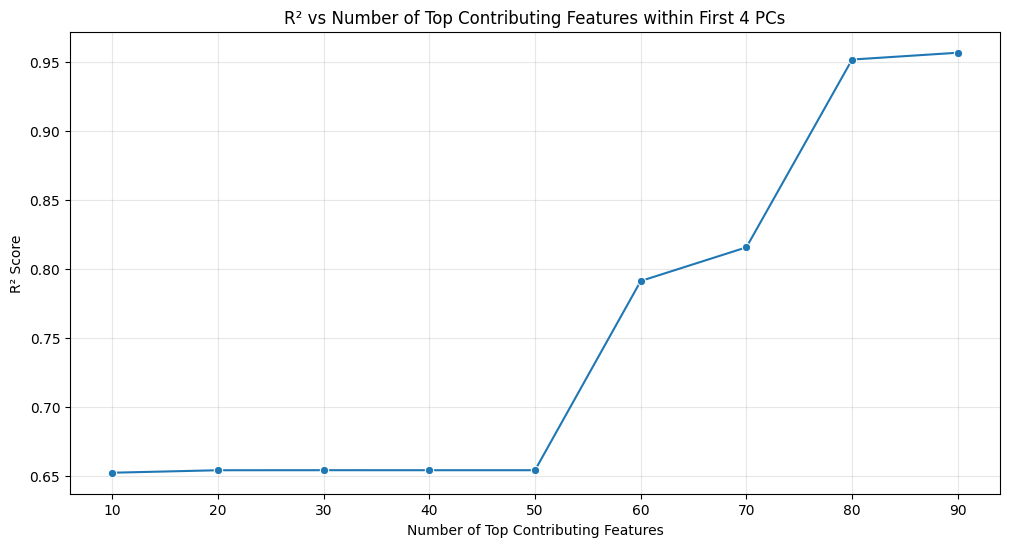

In [114]:
plot_df = pd.DataFrame(plot_data)
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_df, x='Top_features', y='R2', marker='o')
plt.title('R² vs Number of Top Contributing Features within First 4 PCs')
plt.xlabel('Number of Top Contributing Features')
plt.ylabel('R² Score')
plt.grid(alpha=0.3)
plt.show()

It turns out you still need most of the top contributing features for the 3 principal components for good model performance. In this situation, using the top contributing PC features is probably not a good way to feature engineer a lighter model for ridership.

In [107]:
start_year = 2018
end_year = pd.Timestamp.today().year

#Get average seasonal and annual ridership
si_gdf_avg_ridership = si_gdf.copy()

for idx, station in si_gdf_avg_ridership.iterrows():
    map_id = station['MAP_ID']

    station_slice = station_ridership[
        (station_ridership['MAP_ID'] == map_id) &
        (station_ridership['year'] >= start_year) &
        (station_ridership['year'] <= end_year)
    ]

    seasonal_avg = (
        station_slice
        .groupby(['year', 'season'], as_index=False)['rides']
        .mean()
        .rename(columns={'rides': 'avg_rides'})
        .sort_values(['year', 'season'])
    )

    for _, season_row in seasonal_avg.iterrows():
        column_name = f"{int(season_row['year'])}_{season_row['season']}_avg_rides"
        si_gdf_avg_ridership.at[idx, column_name] = season_row['avg_rides']

    annual_avg = (
        station_slice
        .groupby('year', as_index=False)['rides']
        .mean()
        .rename(columns={'rides': 'avg_rides_annual'})
        .sort_values('year')
    )

    for _, year_row in annual_avg.iterrows():
        column_name = f"{int(year_row['year'])}_avg_rides"
        si_gdf_avg_ridership.at[idx, column_name] = year_row['avg_rides_annual']

for column in si_gdf_avg_ridership:
    print(column)


MAP_ID
STATION_NAME
latitude
longitude
ADA
RED
BLUE
G
BRN
P
Y
Pnk
O
N/S
E/W
geometry
geometry_mile
geometry_half_mile
neighborhood_shopping_district_within_mile
neighborhood_shopping_district_within_half_mile
neighborhood_mixed_use_district_within_mile
neighborhood_mixed_use_district_within_half_mile
community_shopping_district_within_mile
community_shopping_district_within_half_mile
neighborhood_commercial_district_within_mile
neighborhood_commercial_district_within_half_mile
motor_vehicle_related_commercial_district_within_mile
motor_vehicle_related_commercial_district_within_half_mile
commercial_manufacturing_and_employment_district_within_mile
commercial_manufacturing_and_employment_district_within_half_mile
downtown_core_district_within_mile
downtown_core_district_within_half_mile
downtown_residential_district_within_mile
downtown_residential_district_within_half_mile
downtown_service_district_within_mile
downtown_service_district_within_half_mile
downtown_mixed_use_district_withi


Average ridership statistics by cluster:


,n_stations,mean,median,std,min,max
cluster,,,,,,
0,11,7179.05,6664.45,1286.57,5733.98,10174.25
1,20,2757.65,2852.42,890.06,1339.25,4172.97
2,63,957.68,904.13,405.76,257.59,1878.81
3,15,833.85,591.93,514.96,423.55,1926.38
4,35,2897.95,2750.68,872.35,1917.27,5050.67



Average ridership statistics by cluster:


,n_stations,mean,median,std,min,max
cluster,,,,,,
0,11,7179.05,6664.45,1286.57,5733.98,10174.25
1,20,2757.65,2852.42,890.06,1339.25,4172.97
2,63,957.68,904.13,405.76,257.59,1878.81
3,15,833.85,591.93,514.96,423.55,1926.38
4,35,2897.95,2750.68,872.35,1917.27,5050.67


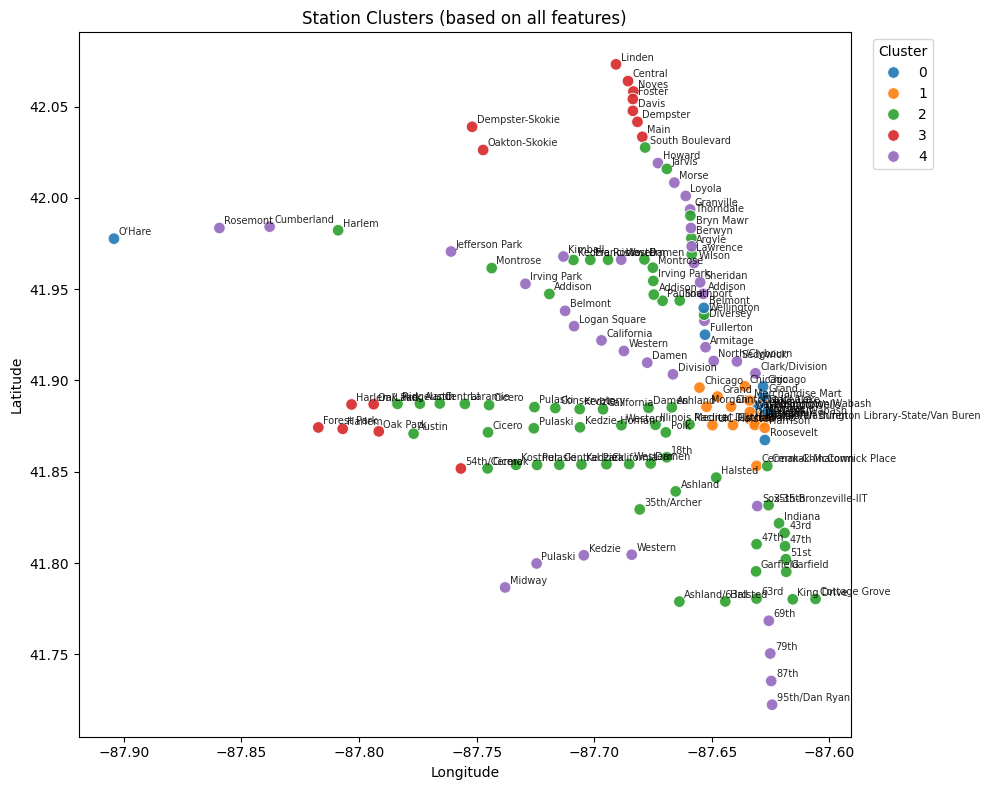

In [108]:

# Use all ridership-average features created in si_gdf_avg_ridership
exclude_cols = {"MAP_ID", "STATION_NAME", "stationname"}
clustering_cols = [
    c for c in si_gdf_avg_ridership.columns
    if c not in exclude_cols and not c.startswith("geometry")
]

if not clustering_cols:
    raise ValueError("No *_avg_rides columns found in si_gdf_avg_ridership.")

# Build clustering matrix (median-impute missing values)
X_cluster = si_gdf_avg_ridership[clustering_cols].copy()
X_cluster = X_cluster.apply(pd.to_numeric, errors="coerce")
X_cluster = X_cluster.fillna(X_cluster.median())

# Scale + cluster
X_scaled = StandardScaler().fit_transform(X_cluster)

k = 5  # adjust if needed
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
si_gdf_avg_ridership["cluster"] = kmeans.fit_predict(X_scaled)



Average ridership statistics by cluster:


,n_stations,mean,median,std,min,max
cluster,,,,,,
0,11,7179.05,6664.45,1286.57,5733.98,10174.25
1,20,2757.65,2852.42,890.06,1339.25,4172.97
2,63,957.68,904.13,405.76,257.59,1878.81
3,15,833.85,591.93,514.96,423.55,1926.38
4,35,2897.95,2750.68,872.35,1917.27,5050.67


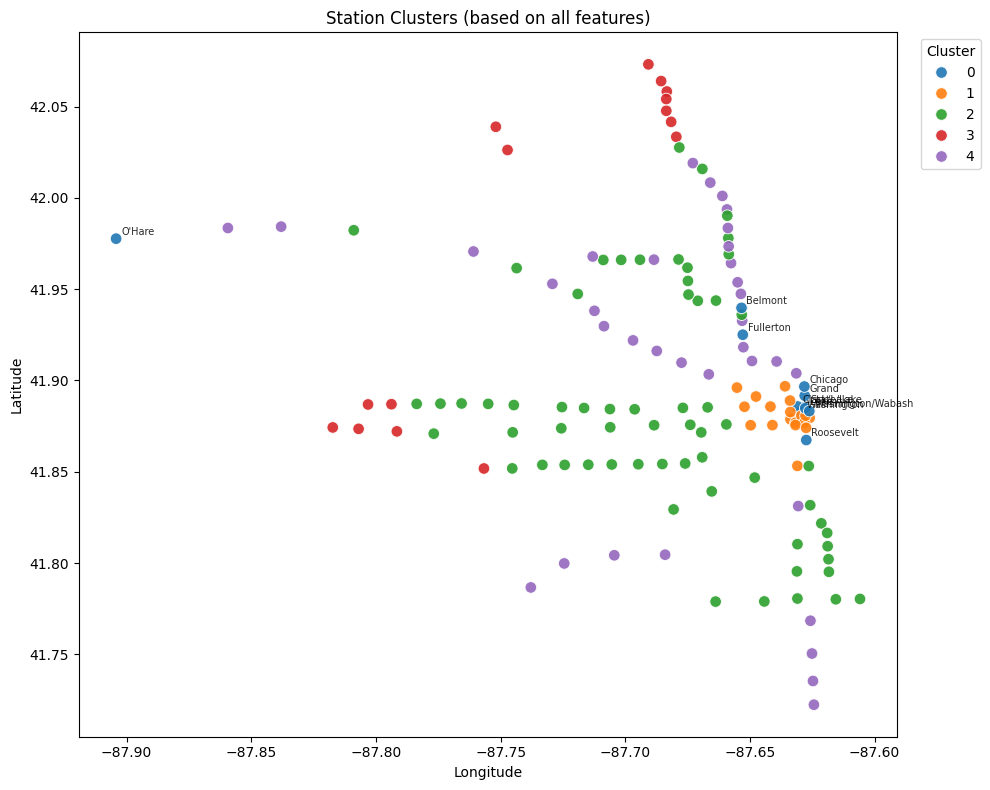

In [120]:

# Quick summary
# Average ridership statistics by cluster
ridership_cols = [c for c in si_gdf_avg_ridership.columns if c.endswith("_avg_rides")]

if ridership_cols:
    cluster_ridership_stats = (
        si_gdf_avg_ridership
        .assign(_station_avg_rides=si_gdf_avg_ridership[ridership_cols].mean(axis=1, skipna=True))
        .groupby("cluster")["_station_avg_rides"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .rename(columns={"count": "n_stations"})
        .round(2)
    )
    print("\nAverage ridership statistics by cluster:")
    display(cluster_ridership_stats)
else:
    print("No *_avg_rides columns found for ridership statistics.")

# Plot clusters by station location
plt.figure(figsize=(10, 8))
label_col = "STATION_NAME" if "STATION_NAME" in si_gdf_avg_ridership.columns else "stationname"
si_gdf_avg_ridership_cluster_ = si_gdf_avg_ridership[si_gdf_avg_ridership["cluster"] == 0].copy()

si_gdf_avg_ridership_cluster_0 = si_gdf_avg_ridership[si_gdf_avg_ridership["cluster"] == 0].copy()

for _, row in si_gdf_avg_ridership_cluster_0.dropna(subset=["longitude", "latitude", [label_col][0]]).iterrows():
    plt.text(
        row["longitude"] + 0.002,
        row["latitude"] + 0.002,
        str(row[label_col]),
        fontsize=7,
        alpha=0.85
    )
sns.scatterplot(
    data=si_gdf_avg_ridership,
    x="longitude",
    y="latitude",
    hue="cluster",
    palette="tab10",
    s=70,
    alpha=0.9
)
plt.title("Station Clusters (based on all features)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

We can see clear clusters. Cluster 0 seems to be high traffic. centered around the Loop, O'hare, Fullerton (a commonly used transfer stop between the red and brown line) and Belmont (close to Wrigleyville and the famous Wrigley Stadium, home of the Chicago Cubs baseball team). Cluster 1 and 4 are medium traffic stations with stations in Cluster 1 being closer to the Loop on average than stations in cluster 4. Clusters 2 and 3 are lower traffic stations with stations in Cluster 2 on average being closer to the Loop than those in Cluster 3.

In [109]:
# Ablation testing to see which features are most important for clustering
from sklearn.metrics import silhouette_score
feature_importance = {}

# Calculate baseline silhouette score
baseline_score = silhouette_score(X_scaled, si_gdf_avg_ridership["cluster"])
print(f"Baseline silhouette score: {baseline_score:.4f}\n")

for col in clustering_cols:
    X_ablated = X_cluster.drop(columns=[col])
    X_ablated_scaled = StandardScaler().fit_transform(X_ablated)
    kmeans_ablated = KMeans(n_clusters=k, n_init=10)
    labels_ablated = kmeans_ablated.fit_predict(X_ablated_scaled)
    score = silhouette_score(X_ablated_scaled, labels_ablated)
    feature_importance[col] = score
feature_importance_df = pd.DataFrame.from_dict(feature_importance, orient="index", columns=["silhouette_score"])
feature_importance_df = feature_importance_df.sort_values(by="silhouette_score", ascending=True)
print("Most important features based on silhouette score after ablation (lower score indicates higher importance):")
display(feature_importance_df)

Baseline silhouette score: 0.2426

Most important features based on silhouette score after ablation (lower score indicates higher importance):


Baseline silhouette score: 0.2426

Most important features based on silhouette score after ablation (lower score indicates higher importance):


,silhouette_score
2024_Summer_avg_rides,0.237234
2022_Winter_avg_rides,0.237637
2019_Summer_avg_rides,0.237687
2021_Winter_avg_rides,0.237752
2021_Spring_avg_rides,0.237793
...,...
O,0.247539
G,0.247561
commercial_manufacturing_and_employment_district_within_half_mile,0.247658
residential_multi_unit_district_within_mile,0.248891


- It looks like each individual feature using clustering doesn't affect the sillhouette score that much, indicating redundant features or weak clusters. The sillhouette score of the unablated model is only 0.23, which isn't the strongest clustering. Let's try again with fewer clusters

Silhouette score with 3 clusters: 0.3169

Average ridership statistics by cluster:


Silhouette score with 3 clusters: 0.3169

Average ridership statistics by cluster:


,n_stations,mean,median,std,min,max
cluster,,,,,,
0,15,833.85,591.93,514.96,423.55,1926.38
1,104,1552.26,1445.91,882.29,257.59,3754.76
2,25,5377.97,4791.97,1877.35,3273.67,10174.25


Silhouette score with 3 clusters: 0.3169

Average ridership statistics by cluster:


,n_stations,mean,median,std,min,max
cluster,,,,,,
0,15,833.85,591.93,514.96,423.55,1926.38
1,104,1552.26,1445.91,882.29,257.59,3754.76
2,25,5377.97,4791.97,1877.35,3273.67,10174.25


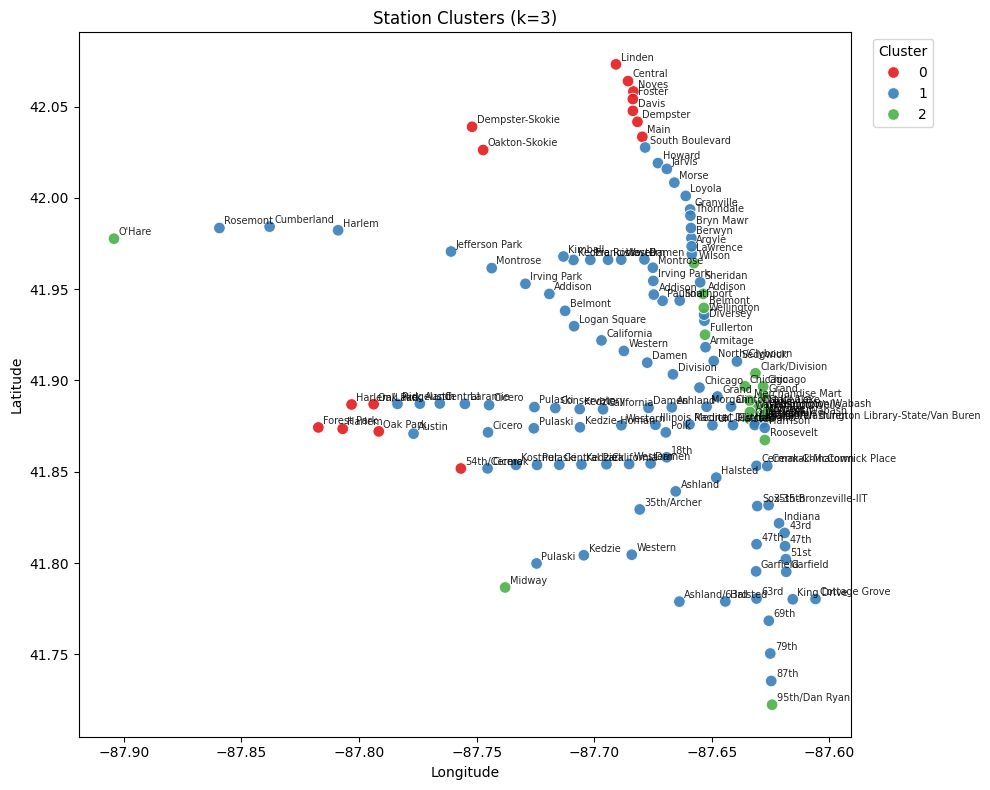

In [110]:
# Retry clustering with k=3 for stronger, more distinct clusters
k = 3

# Work with a copy
si_gdf_avg_ridership_k3 = si_gdf_avg_ridership.copy()

kmeans_3 = KMeans(n_clusters=k, random_state=42, n_init=10)
si_gdf_avg_ridership_k3["cluster"] = kmeans_3.fit_predict(X_scaled)

# Calculate silhouette score
silhouette_3 = silhouette_score(X_scaled, si_gdf_avg_ridership_k3["cluster"])
print(f"Silhouette score with {k} clusters: {silhouette_3:.4f}\n")

# Average ridership statistics by cluster
ridership_cols = [c for c in si_gdf_avg_ridership_k3.columns if c.endswith("_avg_rides")]

if ridership_cols:
    cluster_ridership_stats = (
        si_gdf_avg_ridership_k3
        .assign(_station_avg_rides=si_gdf_avg_ridership_k3[ridership_cols].mean(axis=1, skipna=True))
        .groupby("cluster")["_station_avg_rides"]
        .agg(["count", "mean", "median", "std", "min", "max"])
        .rename(columns={"count": "n_stations"})
        .round(2)
    )
    print("Average ridership statistics by cluster:")
    display(cluster_ridership_stats)

# Plot clusters by station location
plt.figure(figsize=(10, 8))
label_col = "STATION_NAME" if "STATION_NAME" in si_gdf_avg_ridership_k3.columns else "stationname"

for _, row in si_gdf_avg_ridership_k3.dropna(subset=["longitude", "latitude", label_col]).iterrows():
    plt.text(
        row["longitude"] + 0.002,
        row["latitude"] + 0.002,
        str(row[label_col]),
        fontsize=7,
        alpha=0.85
    )
sns.scatterplot(
    data=si_gdf_avg_ridership_k3,
    x="longitude",
    y="latitude",
    hue="cluster",
    palette="Set1",
    s=70,
    alpha=0.9
)
plt.title(f"Station Clusters (k={k})")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Fewer clusters show moderate improvements to sillhouette score. Tradeoff of clearer clusters for nuance

In [115]:
# Ablation test for the k=3 clustering setup (same pattern as before)
feature_importance_k3 = {}

# Ensure k is aligned with the 3-cluster dataframe
k = 3

# Baseline silhouette score using existing scaled matrix and k=3 labels
baseline_score_k3 = silhouette_score(X_scaled, si_gdf_avg_ridership_k3["cluster"])
print(f"Baseline silhouette score (k=3): {baseline_score_k3:.4f}\n")

for col in clustering_cols:
    X_ablated = X_cluster.drop(columns=[col])
    X_ablated_scaled = StandardScaler().fit_transform(X_ablated)
    
    kmeans_ablated = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_ablated = kmeans_ablated.fit_predict(X_ablated_scaled)
    
    score = silhouette_score(X_ablated_scaled, labels_ablated)
    feature_importance_k3[col] = score

feature_importance_k3_df = (
    pd.DataFrame.from_dict(feature_importance_k3, orient="index", columns=["silhouette_score"])
    .assign(delta_vs_baseline=lambda d: d["silhouette_score"] - baseline_score_k3)
    .sort_values(by="silhouette_score", ascending=True)
)

print("Most important features for k=3 ablation (lower silhouette after ablation = more important):")
display(feature_importance_k3_df)

Baseline silhouette score (k=3): 0.3169

Most important features for k=3 ablation (lower silhouette after ablation = more important):


Baseline silhouette score (k=3): 0.3169

Most important features for k=3 ablation (lower silhouette after ablation = more important):


,silhouette_score,delta_vs_baseline
planned_developments_within_half_mile,0.302553,-0.014316
regional_or_community_park_within_mile,0.302772,-0.014097
neighborhood_commercial_district_within_mile,0.304558,-0.012310
planned_developments_within_mile,0.305269,-0.011600
regional_or_community_park_within_half_mile,0.306130,-0.010738
...,...,...
commercial_manufacturing_and_employment_district_within_half_mile,0.321668,0.004800
G,0.321775,0.004907
residential_multi_unit_district_within_half_mile,0.321900,0.005031
heavy_industry_district_within_half_mile,0.321916,0.005048


It seems that ablating each individual feature doesn't affect the silhouette score that much.